# Projeto Final - Análise de eventos LHE

## Parte 1: Leitura do LHE como arquivo texto

Este notebook é uma opção de trabalho para estudantes. Ele nao contém codigo pronto.

A ideia é usar cada célula de instrução para pedir a um agente que gere o código correspondente ao método **texto**. Depois, copie o código produzido pelo agente para a celula vazia logo abaixo e execute no seu ambiente.

Arquivos da amostra:

- sinal: `../data/sinal.lhe.gz`;
- fundo: `../data/fundo.lhe.gz`.

Mantenha as respostas, tabelas, figuras e interpretações no próprio notebook.


## 0. Preparação no Google Colab

Antes de iniciar a análise, siga este fluxo no ambiente do Google Colab:

1. No GitHub, baixe o arquivo ZIP deste repositório (**Code → Download ZIP**) e baixe também o notebook desta tarefa que você vai executar.
2. Abra o notebook no Colab e use o painel **Arquivos** para fazer upload do arquivo `.ipynb` e do arquivo `.zip`. O ZIP deve ficar no mesmo ambiente de execução do notebook, como arquivo de dados.
3. Peça ao agente para gerar e executar um código que localize o ZIP enviado, descompacte o repositório no ambiente do Colab e entre na pasta extraída.
4. Em seguida, peça ao agente para gerar e executar um código que infle (descomprima com `gzip`) `data/sinal.lhe.gz` e `data/fundo.lhe.gz`, criando `data/sinal.lhe` e `data/fundo.lhe`. Mantenha os arquivos `.lhe.gz` originais.
5. Confirme com o agente que a pasta `data/` contém os dois arquivos compactados e as duas versões infladas antes de prosseguir.

Depois dessa preparação, peça ao agente os códigos de cada etapa indicada neste notebook e copie-os nas células de código correspondentes. Use a pasta extraída como diretório de trabalho e mantenha os caminhos relativos aos arquivos de dados.

In [4]:
import glob
import os
import shutil
import zipfile

# 1) Localizar o ZIP enviado ao ambiente do Colab
zip_candidates = glob.glob("/content/*.zip") + glob.glob("./*.zip")
if not zip_candidates:
    raise FileNotFoundError(
        "Nenhum arquivo .zip encontrado em /content ou no diretório atual. "
        "Faça o upload do tarefa4-main.zip pelo painel Arquivos do Colab."
    )
zip_path = zip_candidates[0]
print(f"ZIP encontrado: {zip_path}")

# 2) Descompactar o repositório
extract_root = "/content/repo_extraido"
os.makedirs(extract_root, exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_root)

# 3) Entrar na pasta extraída (normalmente algo como tarefa4-main/)
subdirs = [d for d in glob.glob(os.path.join(extract_root, "*")) if os.path.isdir(d)]
repo_dir = subdirs[0] if len(subdirs) == 1 else extract_root
os.chdir(repo_dir)
print(f"Diretório de trabalho: {os.getcwd()}")

# 4) Inflar sinal.lhe.gz e fundo.lhe.gz, mantendo os .gz originais
import gzip

for nome in ["sinal", "fundo"]:
    caminho_gz = os.path.join("data", f"{nome}.lhe.gz")
    caminho_lhe = os.path.join("data", f"{nome}.lhe")
    if not os.path.exists(caminho_gz):
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_gz}")
    with gzip.open(caminho_gz, "rb") as f_in, open(caminho_lhe, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    print(f"Gerado: {caminho_lhe}")

# 5) Confirmar que data/ contém as quatro versões esperadas
esperado = [
    "data/sinal.lhe.gz", "data/fundo.lhe.gz",
    "data/sinal.lhe", "data/fundo.lhe",
]
print("\nConferência da pasta data/:")
for rel in esperado:
    existe = os.path.exists(rel)
    tamanho = os.path.getsize(rel) if existe else 0
    status = "OK" if existe else "AUSENTE"
    print(f"  [{status}] {rel} ({tamanho} bytes)")

ZIP encontrado: /content/tarefa4-main.zip
Diretório de trabalho: /content/repo_extraido/tarefa4-main
Gerado: data/sinal.lhe
Gerado: data/fundo.lhe

Conferência da pasta data/:
  [OK] data/sinal.lhe.gz (1226411 bytes)
  [OK] data/fundo.lhe.gz (1180963 bytes)
  [OK] data/sinal.lhe (7284019 bytes)
  [OK] data/fundo.lhe (6963207 bytes)


## 1. Leitura dos arquivos LHE

Objetivo: implementar a leitura das amostras de sinal e fundo usando o método designado para este notebook: **Leitura do LHE como arquivo texto**.

Nesta versão, a leitura deve ser feita diretamente a partir do arquivo texto LHE.

Peça ao agente para gerar código em Python que use `gzip.open`, `open`, `split`, expressões regulares ou outra técnica básica de parsing de texto. O codigo deve percorrer os blocos `<event>` e transformar cada evento em estruturas Python claras antes das etapas de validação, histogramas e cutflow.

Não use `pylhe` nesta versão. O objetivo é mostrar que o formato LHE pode ser entendido a partir da sua estrutura textual.

O código deve extrair, no mínimo:

- cabecalho de cada evento;
- `NUP`;
- PDG ID;
- `status`;
- partículas-mãe;
- `px`, `py`, `pz`, energia e massa.

Antes de implementar o parser, peça ao agente uma célula que abra `data/sinal.lhe.gz` e imprima o primeiro bloco completo entre `<event>` e `</event>`. Use essa inspeção para reconhecer o cabeçalho e as linhas das partículas.

Cole o código gerado na célula vazia abaixo.

In [5]:
import gzip

def imprimir_primeiro_evento(caminho_gz):
    with gzip.open(caminho_gz, "rt") as f:
        conteudo = f.read()

    inicio = conteudo.find("<event>")
    fim = conteudo.find("</event>") + len("</event>")
    primeiro_bloco = conteudo[inicio:fim]
    print(primeiro_bloco)
    return primeiro_bloco

print("=== Primeiro evento: sinal ===")
_ = imprimir_primeiro_evento("data/sinal.lhe.gz")

print("\n=== Primeiro evento: fundo ===")
_ = imprimir_primeiro_evento("data/fundo.lhe.gz")

=== Primeiro evento: sinal ===
<event>
5 1 +6.3739000e+02 0.7474288E+02 0.7546771E-02 0.1344669E+00
2   -1    0    0  501    0  0.00000000000E+00  0.00000000000E+00  0.13704169963E+03  0.13704169963E+03  0.00000000000E+00 0.  1.
-2   -1    0    0    0  501 -0.00000000000E+00 -0.00000000000E+00 -0.10191238758E+02  0.10191238758E+02  0.00000000000E+00 0. -1.
23    2    1    2    0    0  0.00000000000E+00  0.00000000000E+00  0.12685046087E+03  0.14723293839E+03  0.74742884094E+02 0.  9.
-11    1    3    3    0    0  0.20792262212E+02 -0.14753936451E+02  0.95998352837E+01  0.27242497062E+02  0.00000000000E+00 0. -1.
11    1    3    3    0    0 -0.20792262212E+02  0.14753936451E+02  0.11725062559E+03  0.11999044132E+03  0.00000000000E+00 0.  1.
</event>

=== Primeiro evento: fundo ===
<event>
5 1 +8.4164000e+02 0.9009532E+02 0.7546771E-02 0.1302621E+00
2   -1    0    0  501    0  0.00000000000E+00  0.00000000000E+00  0.15783425563E+03  0.15783425563E+03  0.00000000000E+00 0. -1.
-2   -1    

In [6]:
import gzip
import re
from dataclasses import dataclass, field
from typing import List

@dataclass
class Particula:
    pdg_id: int
    status: int          # ISTUP: -1 inicial, 1 final, 2 intermediaria
    mae1: int             # indice (1-based) da primeira particula-mae
    mae2: int             # indice (1-based) da segunda particula-mae
    cor1: int
    cor2: int
    px: float
    py: float
    pz: float
    energia: float
    massa: float
    vtim: float
    spin: float

@dataclass
class Evento:
    nup: int              # numero de linhas de particula (NUP)
    idprup: int            # identificador do subprocesso
    peso: float            # XWGTUP
    scalup: float
    aqedup: float
    aqcdup: float
    particulas: List[Particula] = field(default_factory=list)


PADRAO_EVENTO = re.compile(r"<event>(.*?)</event>", re.DOTALL)


def parse_evento(bloco_texto):
    """Converte o texto entre <event> e </event> em um objeto Evento."""
    linhas = [linha.strip() for linha in bloco_texto.strip().split("\n") if linha.strip()]

    # Primeira linha: cabecalho do evento
    campos_cabecalho = linhas[0].split()
    nup, idprup = int(campos_cabecalho[0]), int(campos_cabecalho[1])
    peso, scalup, aqedup, aqcdup = (float(x) for x in campos_cabecalho[2:6])

    particulas = []
    for linha_particula in linhas[1:1 + nup]:
        campos = linha_particula.split()
        particulas.append(
            Particula(
                pdg_id=int(campos[0]),
                status=int(campos[1]),
                mae1=int(campos[2]),
                mae2=int(campos[3]),
                cor1=int(campos[4]),
                cor2=int(campos[5]),
                px=float(campos[6]),
                py=float(campos[7]),
                pz=float(campos[8]),
                energia=float(campos[9]),
                massa=float(campos[10]),
                vtim=float(campos[11]),
                spin=float(campos[12]),
            )
        )

    return Evento(
        nup=nup, idprup=idprup, peso=peso,
        scalup=scalup, aqedup=aqedup, aqcdup=aqcdup,
        particulas=particulas,
    )


def ler_arquivo_lhe(caminho_gz):
    """Le um arquivo .lhe.gz e retorna uma lista de objetos Evento."""
    with gzip.open(caminho_gz, "rt") as f:
        conteudo = f.read()

    eventos = []
    for match in PADRAO_EVENTO.finditer(conteudo):
        eventos.append(parse_evento(match.group(1)))

    return eventos


eventos_sinal = ler_arquivo_lhe("data/sinal.lhe.gz")
eventos_fundo = ler_arquivo_lhe("data/fundo.lhe.gz")

print(f"Eventos de sinal lidos: {len(eventos_sinal)}")
print(f"Eventos de fundo lidos: {len(eventos_fundo)}")

# Checagem rapida do primeiro evento de sinal
ev0 = eventos_sinal[0]
print(f"\nPrimeiro evento (sinal): NUP={ev0.nup}, peso={ev0.peso}, "
      f"IDPRUP={ev0.idprup}")
for p in ev0.particulas:
    print(f"  PDG={p.pdg_id:>4} status={p.status:>2} "
          f"maes=({p.mae1},{p.mae2}) E={p.energia:.3f} m={p.massa:.3f}")

Eventos de sinal lidos: 10000
Eventos de fundo lidos: 10000

Primeiro evento (sinal): NUP=5, peso=637.39, IDPRUP=1
  PDG=   2 status=-1 maes=(0,0) E=137.042 m=0.000
  PDG=  -2 status=-1 maes=(0,0) E=10.191 m=0.000
  PDG=  23 status= 2 maes=(1,2) E=147.233 m=74.743
  PDG= -11 status= 1 maes=(3,3) E=27.242 m=0.000
  PDG=  11 status= 1 maes=(3,3) E=119.990 m=0.000


## 2a. Validação preliminar das amostras

Objetivo: verificar se os arquivos foram lidos corretamente antes de interpretar a física.

Peça ao agente para gerar um código que, para sinal e fundo, calcule:

- número total de eventos;
- distribuição de `NUP`;
- resumo dos informações de normalização;
- canais partônicos iniciais a partir das partículas com `status = -1`;
- frequência da topologia final esperada;
- lista ou contagem de eventos com campos inválidos ou topologia inesperada.

Depois de executar, escreva uma interpretacao curta: as duas amostras parecem consistentes?


In [7]:
import math
from collections import Counter

def resumo_pesos(eventos):
    """Min, max, media, e contagem de pesos problematicos (negativos, nulos, nao finitos)."""
    pesos = [ev.peso for ev in eventos]
    n_negativos = sum(1 for w in pesos if w < 0)
    n_nulos = sum(1 for w in pesos if w == 0)
    n_nao_finitos = sum(1 for w in pesos if not math.isfinite(w))
    pesos_finitos = [w for w in pesos if math.isfinite(w)]
    return {
        "min": min(pesos_finitos) if pesos_finitos else float("nan"),
        "max": max(pesos_finitos) if pesos_finitos else float("nan"),
        "media": sum(pesos_finitos) / len(pesos_finitos) if pesos_finitos else float("nan"),
        "n_negativos": n_negativos,
        "n_nulos": n_nulos,
        "n_nao_finitos": n_nao_finitos,
        "n_total": len(pesos),
    }


def canais_partonicos_iniciais(eventos):
    """Conta combinacoes de PDG ID das particulas com status = -1 (estado inicial)."""
    canais = Counter()
    for ev in eventos:
        iniciais = tuple(sorted(p.pdg_id for p in ev.particulas if p.status == -1))
        canais[iniciais] += 1
    return canais


def topologia_final(eventos):
    """Conta combinacoes de PDG ID das particulas com status = 1 (estado final do gerador)."""
    topologias = Counter()
    for ev in eventos:
        finais = tuple(sorted(p.pdg_id for p in ev.particulas if p.status == 1))
        topologias[finais] += 1
    return topologias


def checar_validade(eventos):
    """
    Verifica campos basicos de consistencia por evento:
    - NUP declarado bate com o numero de linhas de particula lidas;
    - existe pelo menos uma particula com status = -1 e uma com status = 1;
    - energia, massa e momento sao valores finitos;
    - massa nao e negativa.
    """
    eventos_invalidos = []
    for i, ev in enumerate(eventos):
        problemas = []

        if ev.nup != len(ev.particulas):
            problemas.append(f"NUP declarado ({ev.nup}) != particulas lidas ({len(ev.particulas)})")

        if not any(p.status == -1 for p in ev.particulas):
            problemas.append("nenhuma particula com status = -1")

        if not any(p.status == 1 for p in ev.particulas):
            problemas.append("nenhuma particula com status = 1")

        for p in ev.particulas:
            campos = [p.px, p.py, p.pz, p.energia, p.massa]
            if not all(math.isfinite(c) for c in campos):
                problemas.append(f"campo nao finito na particula PDG={p.pdg_id}")
            if p.massa < 0:
                problemas.append(f"massa negativa na particula PDG={p.pdg_id} (m={p.massa})")

        if problemas:
            eventos_invalidos.append((i, problemas))

    return eventos_invalidos


def validar_amostra(nome, eventos, topologia_esperada):
    print(f"\n{'=' * 60}")
    print(f"Amostra: {nome}")
    print(f"{'=' * 60}")

    # Numero total de eventos
    print(f"Numero total de eventos: {len(eventos)}")

    # Distribuicao de NUP
    dist_nup = Counter(ev.nup for ev in eventos)
    print("\nDistribuicao de NUP (numero de particulas por evento):")
    for nup, contagem in sorted(dist_nup.items()):
        fracao = contagem / len(eventos)
        print(f"  NUP={nup}: {contagem} eventos ({fracao:.2%})")

    # Resumo dos pesos
    stats_peso = resumo_pesos(eventos)
    print("\nResumo dos pesos (XWGTUP):")
    print(f"  minimo:      {stats_peso['min']:.6g}")
    print(f"  maximo:      {stats_peso['max']:.6g}")
    print(f"  media:       {stats_peso['media']:.6g}")
    print(f"  negativos:   {stats_peso['n_negativos']} de {stats_peso['n_total']}")
    print(f"  nulos:       {stats_peso['n_nulos']} de {stats_peso['n_total']}")
    print(f"  nao finitos: {stats_peso['n_nao_finitos']} de {stats_peso['n_total']}")

    # Canais partonicos iniciais
    canais = canais_partonicos_iniciais(eventos)
    print("\nCanais partonicos iniciais (PDG IDs de status = -1):")
    for canal, contagem in canais.most_common():
        fracao = contagem / len(eventos)
        print(f"  {canal}: {contagem} eventos ({fracao:.2%})")

    # Topologia final
    topologias = topologia_final(eventos)
    print("\nTopologia final observada (PDG IDs de status = 1):")
    for topo, contagem in topologias.most_common():
        fracao = contagem / len(eventos)
        marcador = " <- esperada" if topo == topologia_esperada else ""
        print(f"  {topo}: {contagem} eventos ({fracao:.2%}){marcador}")

    frac_esperada = topologias.get(topologia_esperada, 0) / len(eventos)
    print(f"\nFracao de eventos com a topologia final esperada {topologia_esperada}: "
          f"{frac_esperada:.2%}")

    # Validade dos campos
    invalidos = checar_validade(eventos)
    print(f"\nEventos com campos invalidos ou topologia/estrutura inesperada: "
          f"{len(invalidos)} de {len(eventos)}")
    if invalidos:
        print("Primeiros exemplos:")
        for i, problemas in invalidos[:5]:
            print(f"  evento {i}: {problemas}")

    return {
        "n_eventos": len(eventos),
        "dist_nup": dist_nup,
        "stats_peso": stats_peso,
        "canais_iniciais": canais,
        "topologias_finais": topologias,
        "eventos_invalidos": invalidos,
    }


# Estado final esperado: e+ e- (PDG 11 = eletron, -11 = positron)
TOPOLOGIA_ESPERADA = tuple(sorted([11, -11]))

resultado_sinal = validar_amostra("sinal (p p > Z > e+ e-)", eventos_sinal, TOPOLOGIA_ESPERADA)
resultado_fundo = validar_amostra("fundo (p p > e+ e-)", eventos_fundo, TOPOLOGIA_ESPERADA)


Amostra: sinal (p p > Z > e+ e-)
Numero total de eventos: 10000

Distribuicao de NUP (numero de particulas por evento):
  NUP=4: 118 eventos (1.18%)
  NUP=5: 9882 eventos (98.82%)

Resumo dos pesos (XWGTUP):
  minimo:      637.39
  maximo:      637.39
  media:       637.39
  negativos:   0 de 10000
  nulos:       0 de 10000
  nao finitos: 0 de 10000

Canais partonicos iniciais (PDG IDs de status = -1):
  (-1, 1): 4151 eventos (41.51%)
  (-2, 2): 3614 eventos (36.14%)
  (-3, 3): 1374 eventos (13.74%)
  (-4, 4): 861 eventos (8.61%)

Topologia final observada (PDG IDs de status = 1):
  (-11, 11): 10000 eventos (100.00%) <- esperada

Fracao de eventos com a topologia final esperada (-11, 11): 100.00%

Eventos com campos invalidos ou topologia/estrutura inesperada: 0 de 10000

Amostra: fundo (p p > e+ e-)
Numero total de eventos: 10000

Distribuicao de NUP (numero de particulas por evento):
  NUP=4: 2593 eventos (25.93%)
  NUP=5: 7407 eventos (74.07%)

Resumo dos pesos (XWGTUP):
  minimo: 

As duas amostras se mostram consistentes com o que se espera dos processos gerados. Nas duas, 100% dos eventos apresentam a topologia final esperada ($e^+ e^-$), além disso, todo evento carrega a mesma fração da seção de choque total. Os canais partônicos iniciais são dominados por $u \bar{u}$ e $d \bar{d}$, refletindo a maior luminosidade de quarks leves no próton. A proporção entre os canais é semelhante nas duas amostras, o que é esperado visto que as duas envolvem o mesmo tipo de aniquilação $q \bar{q}$ no estado inicial.

A maior diferença está na distribuição de NUP: no sinal, 98,82% dos eventos têm 5 partículas registradas, contra 74,07% no fundo.

## 2b. Inventário de partículas e identificação dos processos

Objetivo: construir uma tabela das particulas presentes no LHE.

Peça ao agente para gerar um código que produza uma tabela separando partículas por PDG, ID e `status`. A tabela deve mostrar:

- nome ou interpretação da partícula;
- `status`;
- número total de ocorrências;
- número de eventos em que aparece;
- fraçãoo dos eventos;
- papel físico no processo.

Use a tabela e os cartões do MadGraph registrados no LHE para responder:

- qual é o processo de sinal;
- qual é o processo de fundo;
- por que ambos podem produzir o mesmo estado final observável.


In [8]:
import pandas as pd
from collections import defaultdict

# Nomes e papel fisico de referencia para os PDG IDs que aparecem nas amostras
INFO_PDG = {
    1:  ("d (quark down)",        "parton de valencia/mar do proton, estado inicial"),
    -1: ("dbar (antiquark down)", "parton do mar do proton, estado inicial"),
    2:  ("u (quark up)",          "parton de valencia/mar do proton, estado inicial"),
    -2: ("ubar (antiquark up)",   "parton do mar do proton, estado inicial"),
    3:  ("s (quark strange)",     "parton do mar do proton, estado inicial"),
    -3: ("sbar (antiquark strange)", "parton do mar do proton, estado inicial"),
    4:  ("c (quark charm)",       "parton do mar do proton, estado inicial"),
    -4: ("cbar (antiquark charm)", "parton do mar do proton, estado inicial"),
    21: ("g (gluon)",             "parton do mar do proton, estado inicial"),
    11: ("e- (eletron)",          "lepton carregado do estado final, diretamente detectavel"),
    -11:("e+ (positron)",         "lepton carregado do estado final, diretamente detectavel"),
    23: ("Z (boson Z)",           "propagador intermediario, resonancia do sinal (q qbar -> Z -> e+ e-)"),
    22: ("gamma (foton)",         "propagador intermediario (canal gamma*), contribui ao continuo Drell-Yan"),
}

def descrever_pdg(pdg_id):
    nome, papel = INFO_PDG.get(pdg_id, (f"PDG {pdg_id} (desconhecido)", "papel nao catalogado"))
    return nome, papel


def inventario_particulas(eventos):
    """
    Conta ocorrencias totais e numero de eventos em que cada combinacao
    (pdg_id, status) aparece.
    """
    ocorrencias_totais = defaultdict(int)   # (pdg_id, status) -> total de linhas
    eventos_com_particula = defaultdict(int)  # (pdg_id, status) -> numero de eventos distintos

    for ev in eventos:
        presentes_no_evento = set()
        for p in ev.particulas:
            chave = (p.pdg_id, p.status)
            ocorrencias_totais[chave] += 1
            presentes_no_evento.add(chave)
        for chave in presentes_no_evento:
            eventos_com_particula[chave] += 1

    n_eventos = len(eventos)
    linhas = []
    for (pdg_id, status), total in ocorrencias_totais.items():
        nome, papel = descrever_pdg(pdg_id)
        n_eventos_com = eventos_com_particula[(pdg_id, status)]
        linhas.append({
            "PDG ID": pdg_id,
            "particula": nome,
            "status": status,
            "ocorrencias_totais": total,
            "n_eventos": n_eventos_com,
            "fracao_eventos": n_eventos_com / n_eventos,
            "papel_fisico": papel,
        })

    tabela = pd.DataFrame(linhas).sort_values(
        by=["status", "ocorrencias_totais"], ascending=[True, False]
    ).reset_index(drop=True)
    return tabela


print("=== Inventario de particulas: sinal (p p > Z > e+ e-) ===")
tabela_sinal = inventario_particulas(eventos_sinal)
display(tabela_sinal)

print("\n=== Inventario de particulas: fundo (p p > e+ e-) ===")
tabela_fundo = inventario_particulas(eventos_fundo)
display(tabela_fundo)

=== Inventario de particulas: sinal (p p > Z > e+ e-) ===


,PDG ID,particula,status,ocorrencias_totais,n_eventos,fracao_eventos,papel_fisico
0,1,d (quark down),-1,4151,4151,0.4151,"parton de valencia/mar do proton, estado inicial"
1,-1,dbar (antiquark down),-1,4151,4151,0.4151,"parton do mar do proton, estado inicial"
2,2,u (quark up),-1,3614,3614,0.3614,"parton de valencia/mar do proton, estado inicial"
3,-2,ubar (antiquark up),-1,3614,3614,0.3614,"parton do mar do proton, estado inicial"
4,3,s (quark strange),-1,1374,1374,0.1374,"parton do mar do proton, estado inicial"
5,-3,sbar (antiquark strange),-1,1374,1374,0.1374,"parton do mar do proton, estado inicial"
6,-4,cbar (antiquark charm),-1,861,861,0.0861,"parton do mar do proton, estado inicial"
7,4,c (quark charm),-1,861,861,0.0861,"parton do mar do proton, estado inicial"
8,-11,e+ (positron),1,10000,10000,1.0000,"lepton carregado do estado final, diretamente ..."
9,11,e- (eletron),1,10000,10000,1.0000,"lepton carregado do estado final, diretamente ..."



=== Inventario de particulas: fundo (p p > e+ e-) ===


,PDG ID,particula,status,ocorrencias_totais,n_eventos,fracao_eventos,papel_fisico
0,2,u (quark up),-1,4311,4311,0.4311,"parton de valencia/mar do proton, estado inicial"
1,-2,ubar (antiquark up),-1,4311,4311,0.4311,"parton do mar do proton, estado inicial"
2,-1,dbar (antiquark down),-1,3492,3492,0.3492,"parton do mar do proton, estado inicial"
3,1,d (quark down),-1,3492,3492,0.3492,"parton de valencia/mar do proton, estado inicial"
4,3,s (quark strange),-1,1140,1140,0.1140,"parton do mar do proton, estado inicial"
5,-3,sbar (antiquark strange),-1,1140,1140,0.1140,"parton do mar do proton, estado inicial"
6,4,c (quark charm),-1,1057,1057,0.1057,"parton do mar do proton, estado inicial"
7,-4,cbar (antiquark charm),-1,1057,1057,0.1057,"parton do mar do proton, estado inicial"
8,-11,e+ (positron),1,10000,10000,1.0000,"lepton carregado do estado final, diretamente ..."
9,11,e- (eletron),1,10000,10000,1.0000,"lepton carregado do estado final, diretamente ..."


- Processo de sinal: $$pp \to Z \to e^+ e^-,$$ produção de um bóson $Z$ que decai em par elétron-pósitron. O $Z$ é ressonante, por isso aparece como propagador explícito em quase todos os eventos.

- Processo de fundo: $$pp \to e^+ e^-,$$ produção de $e^+ e^-$ sem exigir passagem pelo polo do $Z$.

- Por que produzem o mesmo estado final observável: ambos os processos partem de aniquilação $q \bar{q}$ e terminam em $e^+ e^-$, o estado final visível é indistinguível partícula a partícula. A diferença física está na massa invariante do par $e^+ e^-$ que no sinal se concentra perto de $\sim 91$ GeV (massa do $Z$), equanto no fundo se espalha ao longo de todo o espectro acessível.

## 3a. Variáveis cinemáticas por partícula

Objetivo: construir histogramas de `pT`, `eta` e `phi` para partículas finais visíveis.

Peça ao agente para gerar um código que selecione partículas com `status = 1`, remova neutrinos e construa histogramas comparando sinal e fundo para cada espécie relevante.

Intervalos sugeridos:

- `pT`: 0 a 100 GeV;
- `eta`: -3 a +3;
- `phi`: -pi a +pi.

Os histogramas devem informar:

- número de entradas;
- número e fração de eventos representados;
- underflow;
- overflow;
- incerteza estatística por bin.

Salve as figuras em `../resultados/graficos/`.


Especies finais visiveis encontradas: ['e+', 'e-']


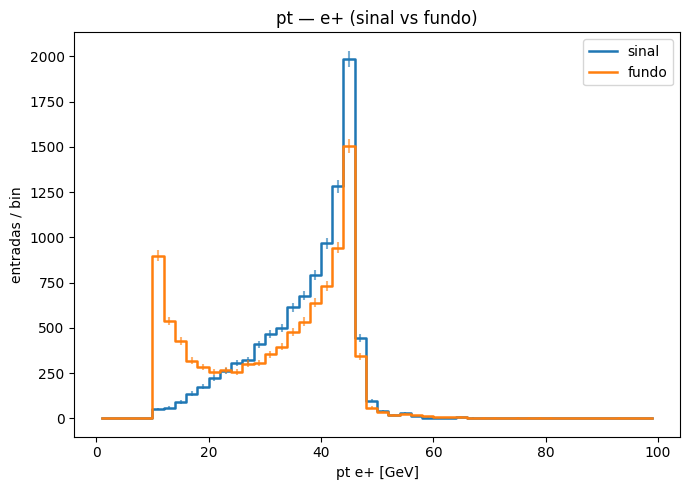


--- pt de e+ ---
  [sinal] entradas totais: 10000  | no intervalo: 9995  | underflow: 0  | overflow: 5
  [sinal] eventos com essa especie: 10000 (100.00% da amostra)
  [fundo] entradas totais: 10000  | no intervalo: 9993  | underflow: 0  | overflow: 7
  [fundo] eventos com essa especie: 10000 (100.00% da amostra)
  figura salva em: ../resultados/graficos/pt_e+.png


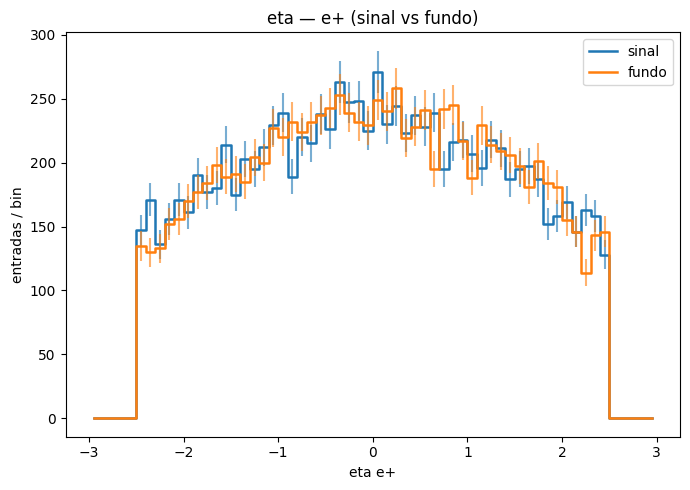


--- eta de e+ ---
  [sinal] entradas totais: 10000  | no intervalo: 10000  | underflow: 0  | overflow: 0
  [sinal] eventos com essa especie: 10000 (100.00% da amostra)
  [fundo] entradas totais: 10000  | no intervalo: 10000  | underflow: 0  | overflow: 0
  [fundo] eventos com essa especie: 10000 (100.00% da amostra)
  figura salva em: ../resultados/graficos/eta_e+.png


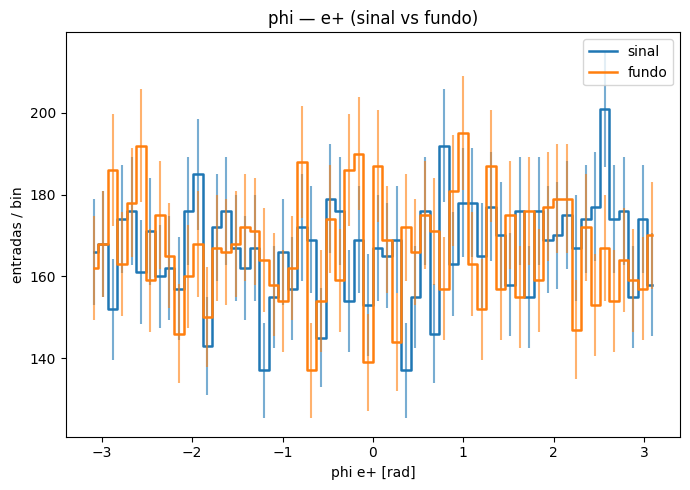


--- phi de e+ ---
  [sinal] entradas totais: 10000  | no intervalo: 10000  | underflow: 0  | overflow: 0
  [sinal] eventos com essa especie: 10000 (100.00% da amostra)
  [fundo] entradas totais: 10000  | no intervalo: 10000  | underflow: 0  | overflow: 0
  [fundo] eventos com essa especie: 10000 (100.00% da amostra)
  figura salva em: ../resultados/graficos/phi_e+.png


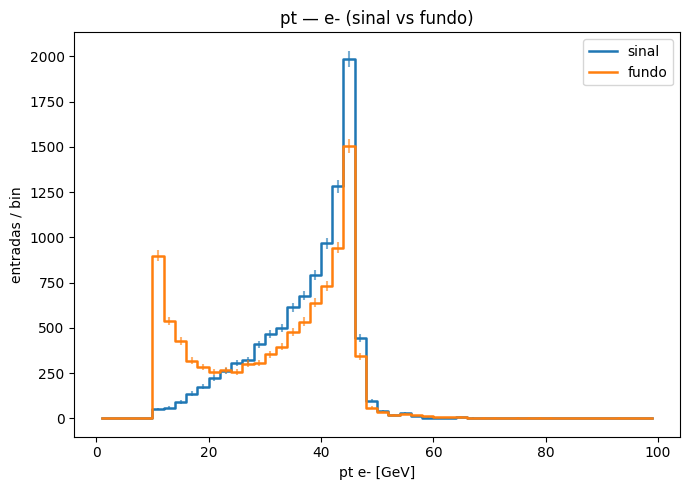


--- pt de e- ---
  [sinal] entradas totais: 10000  | no intervalo: 9995  | underflow: 0  | overflow: 5
  [sinal] eventos com essa especie: 10000 (100.00% da amostra)
  [fundo] entradas totais: 10000  | no intervalo: 9993  | underflow: 0  | overflow: 7
  [fundo] eventos com essa especie: 10000 (100.00% da amostra)
  figura salva em: ../resultados/graficos/pt_e-.png


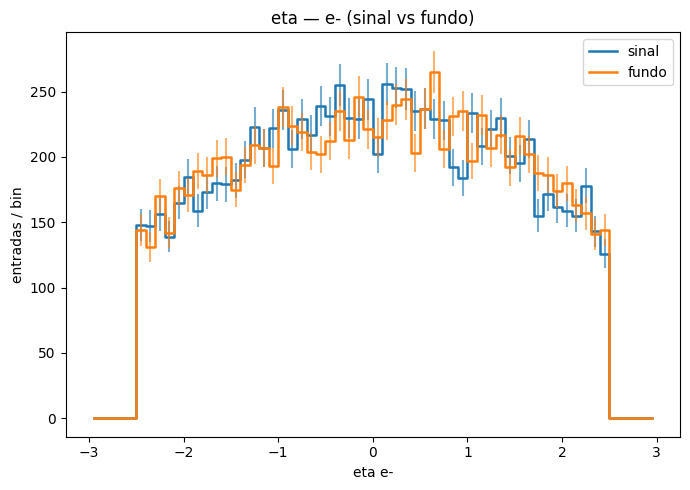


--- eta de e- ---
  [sinal] entradas totais: 10000  | no intervalo: 10000  | underflow: 0  | overflow: 0
  [sinal] eventos com essa especie: 10000 (100.00% da amostra)
  [fundo] entradas totais: 10000  | no intervalo: 10000  | underflow: 0  | overflow: 0
  [fundo] eventos com essa especie: 10000 (100.00% da amostra)
  figura salva em: ../resultados/graficos/eta_e-.png


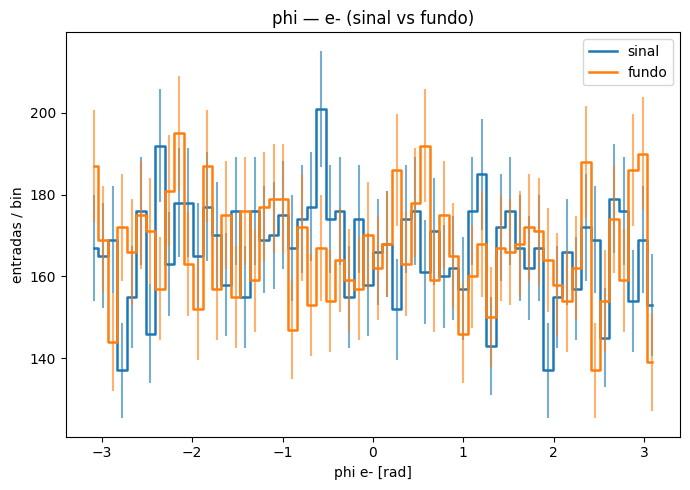


--- phi de e- ---
  [sinal] entradas totais: 10000  | no intervalo: 10000  | underflow: 0  | overflow: 0
  [sinal] eventos com essa especie: 10000 (100.00% da amostra)
  [fundo] entradas totais: 10000  | no intervalo: 10000  | underflow: 0  | overflow: 0
  [fundo] eventos com essa especie: 10000 (100.00% da amostra)
  figura salva em: ../resultados/graficos/phi_e-.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../resultados/graficos", exist_ok=True)

# PDG IDs de neutrinos, a excluir por serem invisiveis (nao interagem no detector)
PDG_NEUTRINOS = {12, -12, 14, -14, 16, -16}

NOME_PARTICULA = {
    11: "e-", -11: "e+",
    13: "mu-", -13: "mu+",
    22: "gamma",
    1: "d", -1: "dbar", 2: "u", -2: "ubar",
    3: "s", -3: "sbar", 4: "c", -4: "cbar", 21: "g",
}


def cinematica(p):
    """Calcula pT, eta e phi a partir de px, py, pz de uma Particula."""
    pt = math.hypot(p.px, p.py)
    p_total = math.sqrt(p.px**2 + p.py**2 + p.pz**2)
    if pt > 0:
        eta = math.asinh(p.pz / pt)
    else:
        eta = math.copysign(float("inf"), p.pz)  # particula exatamente ao longo do eixo do feixe
    phi = math.atan2(p.py, p.px)
    return pt, eta, phi


def coletar_particulas_finais_visiveis(eventos):
    """
    Para cada evento, seleciona particulas com status = 1, exclui neutrinos,
    e retorna um dicionario {pdg_id: {'pt': [...], 'eta': [...], 'phi': [...],
    'evento_idx': [...]}}.
    """
    dados_por_especie = defaultdict(lambda: {"pt": [], "eta": [], "phi": [], "evento_idx": []})

    for i, ev in enumerate(eventos):
        for p in ev.particulas:
            if p.status != 1:
                continue
            if p.pdg_id in PDG_NEUTRINOS:
                continue
            pt, eta, phi = cinematica(p)
            d = dados_por_especie[p.pdg_id]
            d["pt"].append(pt)
            d["eta"].append(eta)
            d["phi"].append(phi)
            d["evento_idx"].append(i)

    return dados_por_especie


def resumo_histograma(valores, bins, xmin, xmax, n_eventos_amostra, n_eventos_especie):
    """Estatisticas de um histograma: entradas, eventos, fracao, underflow, overflow, incerteza por bin."""
    valores = np.asarray(valores)
    dentro = valores[(valores >= xmin) & (valores <= xmax)]
    underflow = int(np.sum(valores < xmin))
    overflow = int(np.sum(valores > xmax))

    contagens, bordas = np.histogram(dentro, bins=bins, range=(xmin, xmax))
    incerteza_por_bin = np.sqrt(contagens)  # contagem nao ponderada: incerteza = sqrt(N)

    return {
        "entradas_totais": len(valores),
        "entradas_no_intervalo": len(dentro),
        "n_eventos_especie": n_eventos_especie,
        "fracao_eventos": n_eventos_especie / n_eventos_amostra,
        "underflow": underflow,
        "overflow": overflow,
        "contagens_por_bin": contagens,
        "bordas_bin": bordas,
        "incerteza_por_bin": incerteza_por_bin,
    }


def plotar_e_resumir(nome_var, unidade, xmin, xmax, n_bins,
                      dados_sinal, dados_fundo, n_ev_sinal, n_ev_fundo, chave):
    """Gera histograma comparando sinal e fundo para uma variavel (pt, eta ou phi) de uma especie."""
    valores_sinal = dados_sinal[chave][nome_var]
    valores_fundo = dados_fundo[chave][nome_var]

    n_ev_especie_sinal = len(set(dados_sinal[chave]["evento_idx"]))
    n_ev_especie_fundo = len(set(dados_fundo[chave]["evento_idx"]))

    resumo_s = resumo_histograma(valores_sinal, n_bins, xmin, xmax, n_ev_sinal, n_ev_especie_sinal)
    resumo_f = resumo_histograma(valores_fundo, n_bins, xmin, xmax, n_ev_fundo, n_ev_especie_fundo)

    nome_particula = NOME_PARTICULA.get(chave, f"PDG {chave}")

    fig, ax = plt.subplots(figsize=(7, 5))
    centros = 0.5 * (resumo_s["bordas_bin"][:-1] + resumo_s["bordas_bin"][1:])
    largura = resumo_s["bordas_bin"][1] - resumo_s["bordas_bin"][0]

    ax.step(centros, resumo_s["contagens_por_bin"], where="mid", label="sinal", linewidth=1.8)
    ax.errorbar(centros, resumo_s["contagens_por_bin"], yerr=resumo_s["incerteza_por_bin"],
                fmt="none", ecolor="C0", alpha=0.6)

    ax.step(centros, resumo_f["contagens_por_bin"], where="mid", label="fundo", linewidth=1.8)
    ax.errorbar(centros, resumo_f["contagens_por_bin"], yerr=resumo_f["incerteza_por_bin"],
                fmt="none", ecolor="C1", alpha=0.6)

    ax.set_xlabel(f"{nome_var} {nome_particula} [{unidade}]" if unidade else f"{nome_var} {nome_particula}")
    ax.set_ylabel("entradas / bin")
    ax.set_title(f"{nome_var} — {nome_particula} (sinal vs fundo)")
    ax.legend()
    fig.tight_layout()

    caminho_fig = f"../resultados/graficos/{nome_var}_{nome_particula.replace('/', '-')}.png"
    fig.savefig(caminho_fig, dpi=150)
    plt.show()
    plt.close(fig)

    print(f"\n--- {nome_var} de {nome_particula} ---")
    for rotulo, resumo in [("sinal", resumo_s), ("fundo", resumo_f)]:
        print(f"  [{rotulo}] entradas totais: {resumo['entradas_totais']}  "
              f"| no intervalo: {resumo['entradas_no_intervalo']}  "
              f"| underflow: {resumo['underflow']}  | overflow: {resumo['overflow']}")
        print(f"  [{rotulo}] eventos com essa especie: {resumo['n_eventos_especie']} "
              f"({resumo['fracao_eventos']:.2%} da amostra)")
    print(f"  figura salva em: {caminho_fig}")

    return resumo_s, resumo_f


import math  # usado em cinematica()

# Coleta das particulas finais visiveis (exclui status != 1 e neutrinos)
dados_sinal = coletar_particulas_finais_visiveis(eventos_sinal)
dados_fundo = coletar_particulas_finais_visiveis(eventos_fundo)

n_ev_sinal = len(eventos_sinal)
n_ev_fundo = len(eventos_fundo)

# Especies presentes em pelo menos uma das duas amostras
especies = sorted(set(dados_sinal.keys()) | set(dados_fundo.keys()))
print(f"Especies finais visiveis encontradas: "
      f"{[NOME_PARTICULA.get(e, e) for e in especies]}")

resultados_histogramas = {}
for especie in especies:
    if especie not in dados_sinal or especie not in dados_fundo:
        print(f"Aviso: PDG {especie} presente em apenas uma das amostras, pulando comparacao.")
        continue

    resultados_histogramas[(especie, "pt")] = plotar_e_resumir(
        "pt", "GeV", 0, 100, 50, dados_sinal, dados_fundo, n_ev_sinal, n_ev_fundo, especie
    )
    resultados_histogramas[(especie, "eta")] = plotar_e_resumir(
        "eta", "", -3, 3, 60, dados_sinal, dados_fundo, n_ev_sinal, n_ev_fundo, especie
    )
    resultados_histogramas[(especie, "phi")] = plotar_e_resumir(
        "phi", "rad", -math.pi, math.pi, 60, dados_sinal, dados_fundo, n_ev_sinal, n_ev_fundo, especie
    )

## 3b. Interpretação dos histogramas

Objetivo: interpretar as distribuições antes de aplicar cortes.

Depois de executar os histogramas, responda no notebook:

- todos os eventos aparecem em todos os histogramas?
- quando o número de entradas difere do número de eventos?
- quais distribuições separam melhor sinal e fundo?
- quais diferenças de forma podem ser ligadas ao processo físico?
- há algum efeito de intervalo, underflow ou overflow que possa distorcer a leitura?

Peça ao agente para ajudar a organizar essa discussao com base nas tabelas e figuras que você gerou.


- Todos os eventos aparecem em todos os histogramas?

  Sim, para as variáveis por partícula ($p_T$, $\eta$, $\phi$ de $e^-$ e de $e^+$), como o estado final é 100% $e^+ e^-$ em ambas as amostras, toda amostra contribui com exatamente uma entrada de $e^-$ e uma de $e^+$ por evento.

- Quando o número de entradas difere do número de eventos?

  Neste caso específico não difere, como cada evento tem exatamente um $e^-$ e um $e^+$⁺, entradas = eventos para cada espécie. Isso mudaria se houvesse múltiplas partículas da mesma espécie por evento.

- Quais distribuições separam melhor sinal e fundo?

  O $p_T$ é claramente a variável mais discriminante, já que o sinal mostra um pico acentuado próximo de $\sim 45$ GeV, enquanto o fundo tem uma distribuição bem mais suave e um excesso relativo em $p_T$ baixo (perto do corte de geração em $10$ GeV). Já $\eta$ e $\phi$ têm formas quase idênticas entre sinal e fundo, $\eta$ é simétrica e larga, e $\phi$ é uniforme (não há eixo azimutal preferencial), como esperado pela simetria do processo. Essas duas variáveis, isoladamente, não separam sinal de fundo.

- Quais diferenças de forma podem ser ligadas ao processo físico?

  O pico em $p_T \approx 45$ GeV no sinal é a assinatura cinemática do decaimento de $Z$. O fundo, sendo um contínuo em massa invariante, tem elétrons com $p_T$ distribuído ao longo de uma faixa maior de valores, sem um valor dominante tão pronunciado, e mais eventos concentrados perto do limiar de geração ($10$ GeV), refletindo massas invariantes menores no par $e^+ e^-$.

- Há efeito de intervalo, underflow ou overflow que possa distorcer a leitura?

  Sim, mas de origem física (de geração), não um artefato do código. A queda abrupta a zero em $|\eta| > 2,5$ e a subida abrupta em $p_T = 10$ GeV correspondem aos cortes de geração do MadGraph (`eta= 2.5`, `ptl = 10` GeV), não a uma limitação da leitura do LHE. Isso significa que os histogramas cobrem essencialmente toda a distribuição gerada, o underflow em $p_T$ é zero, e o overflow acima de $100$ GeV é desprezível, já que o pico do sinal está bem dentro do intervalo.

## 3c. Variáveis em nível de evento

Objetivo: resumir cada evento por objetos líderes, multiplicidades e separações angulares.

Peça ao agente para gerar um código que calcule, quando fizer sentido para o processo:

- `pT` do objeto líder e sublíder;
- multiplicidade de objetos finais;
- maior valor de `|eta|`;
- menor `pT` entre objetos selecionados;
- `Delta eta`, `Delta phi` e `Delta R` entre pares relevantes.

Construa tabelas e histogramas comparando sinal e fundo.


=== Resumo estatistico (sinal) ===


,multiplicidade,pt_lider,pt_sublider,maior_abs_eta,menor_pt,delta_eta,delta_phi,delta_r
count,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2.0,37.395639,37.395639,1.533854,37.395639,-0.017424,-2.718734,3.451424
std,0.0,9.263221,9.263221,0.608620,9.263221,1.478565,1.574273,0.378858
min,2.0,10.048422,10.048422,0.016199,10.048422,-4.310774,-3.141593,3.141593
25%,2.0,31.971833,31.971833,1.071906,31.971833,-1.054804,-3.141593,3.177302
50%,2.0,39.812150,39.812150,1.585136,39.812150,-0.008065,-3.141593,3.305325
75%,2.0,44.202633,44.202633,2.051331,44.202633,0.993265,-3.141593,3.589895
max,2.0,222.670408,222.670408,2.499772,222.670408,4.458625,3.141593,5.454259



=== Resumo estatistico (fundo) ===


,multiplicidade,pt_lider,pt_sublider,maior_abs_eta,menor_pt,delta_eta,delta_phi,delta_r
count,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2.0,32.243697,32.243697,1.520319,32.243697,-0.012223,-2.749522,3.411342
std,0.0,13.221002,13.221002,0.609048,13.221002,1.374581,1.519857,0.348997
min,2.0,10.002565,10.002565,0.013779,10.002565,-4.286082,-3.141593,3.141593
25%,2.0,20.200724,20.200724,1.054821,20.200724,-0.931459,-3.141593,3.168981
50%,2.0,35.705031,35.705031,1.574061,35.705031,-0.007437,-3.141593,3.274207
75%,2.0,43.205471,43.205471,2.035398,43.205471,0.908145,-3.141593,3.517807
max,2.0,205.385525,205.385525,2.499836,205.385525,4.416568,3.141593,5.419933



=== Distribuicao de multiplicidade (sinal) ===
multiplicidade
2    1.0
Name: proportion, dtype: float64

=== Distribuicao de multiplicidade (fundo) ===
multiplicidade
2    1.0
Name: proportion, dtype: float64


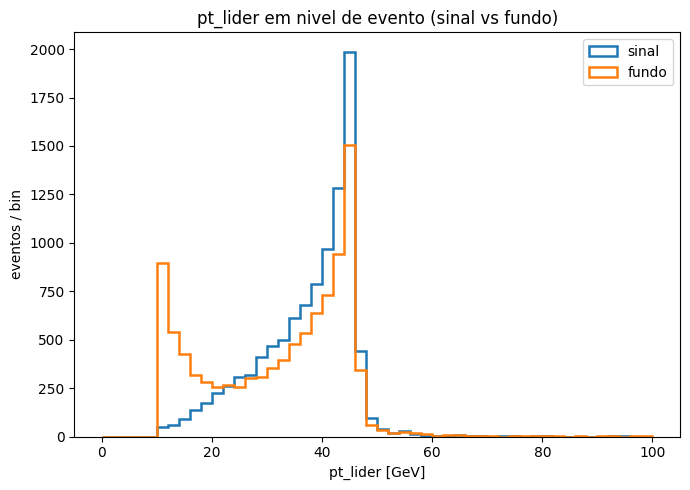

figura salva em: ../resultados/graficos/evento_pt_lider.png


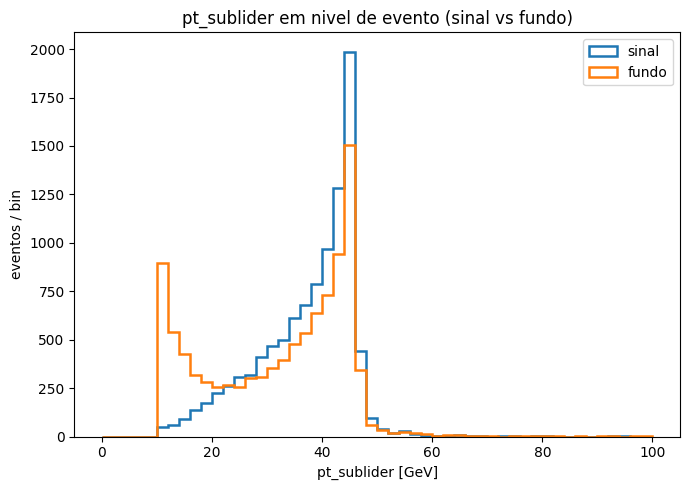

figura salva em: ../resultados/graficos/evento_pt_sublider.png


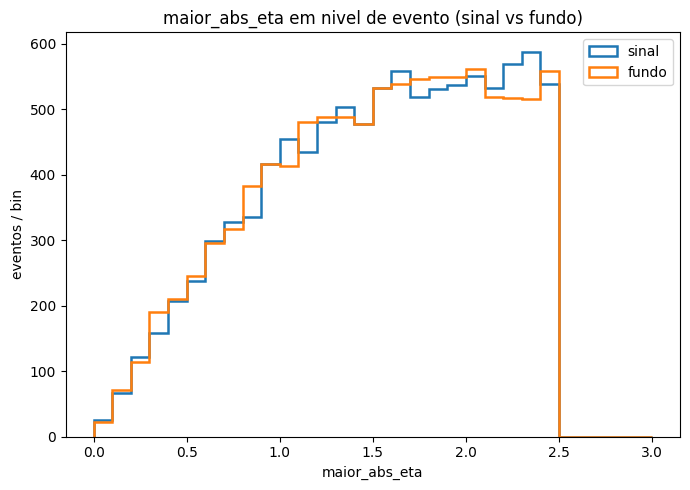

figura salva em: ../resultados/graficos/evento_maior_abs_eta.png


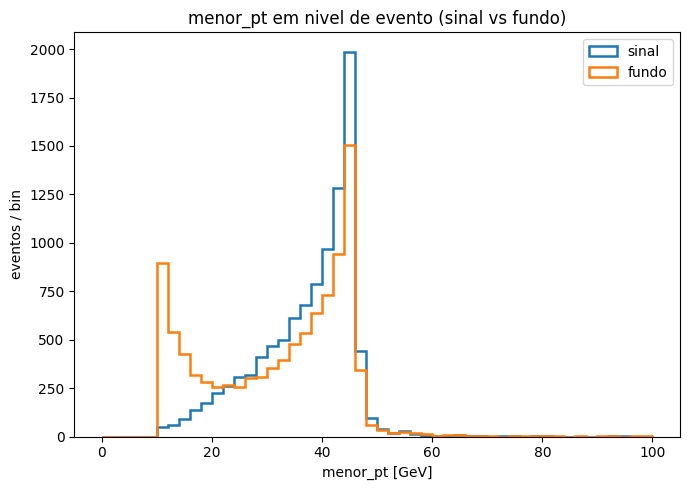

figura salva em: ../resultados/graficos/evento_menor_pt.png


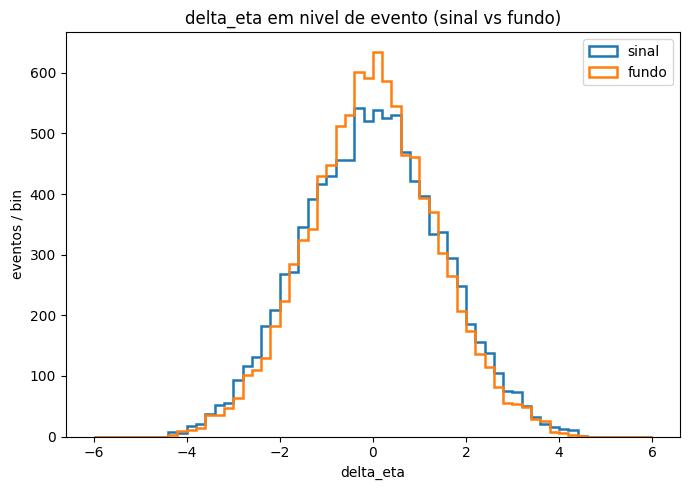

figura salva em: ../resultados/graficos/evento_delta_eta.png


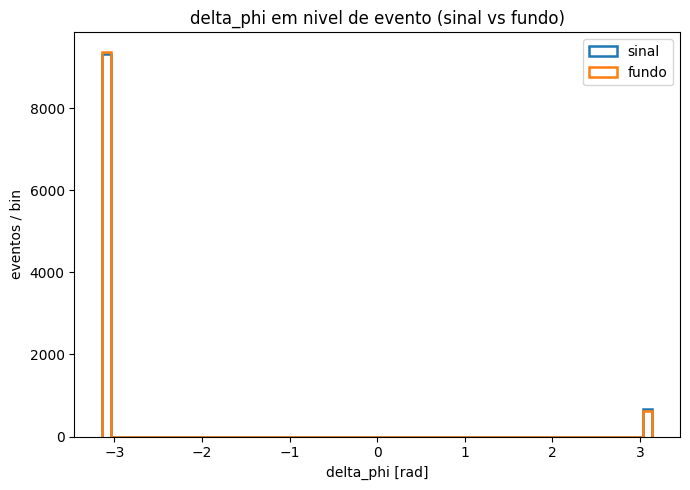

figura salva em: ../resultados/graficos/evento_delta_phi.png


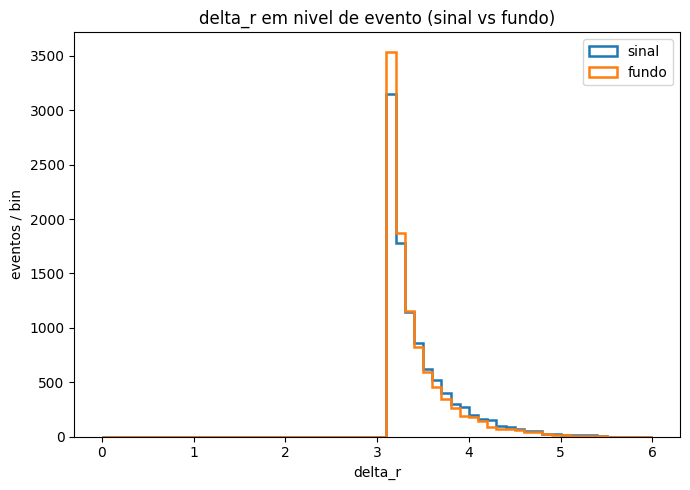

figura salva em: ../resultados/graficos/evento_delta_r.png


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

def delta_phi(phi1, phi2):
    """Diferenca de phi already enrolada para o intervalo (-pi, pi]."""
    dphi = phi1 - phi2
    return (dphi + math.pi) % (2 * math.pi) - math.pi


def variaveis_evento(ev):
    """
    Para um unico evento, seleciona particulas finais visiveis (status=1,
    sem neutrinos) e calcula variaveis de resumo em nivel de evento.
    """
    objetos = []
    for p in ev.particulas:
        if p.status != 1 or p.pdg_id in PDG_NEUTRINOS:
            continue
        pt, eta, phi = cinematica(p)
        objetos.append({"pdg_id": p.pdg_id, "pt": pt, "eta": eta, "phi": phi})

    multiplicidade = len(objetos)
    if multiplicidade == 0:
        return None  # evento sem objetos visiveis (nao esperado nestas amostras)

    objetos_ordenados = sorted(objetos, key=lambda o: o["pt"], reverse=True)
    pt_lider = objetos_ordenados[0]["pt"]
    pt_sublider = objetos_ordenados[1]["pt"] if multiplicidade >= 2 else float("nan")

    maior_abs_eta = max(abs(o["eta"]) for o in objetos)
    menor_pt = min(o["pt"] for o in objetos)

    # Separacao angular entre o par mais relevante: aqui, os dois objetos
    # lideres (no nosso caso, sempre o par e+ e-). Para processos com mais
    # objetos, o criterio de pareamento deveria ser declarado explicitamente
    # (ex.: apenas pares de carga oposta da mesma especie).
    if multiplicidade >= 2:
        o1, o2 = objetos_ordenados[0], objetos_ordenados[1]
        d_eta = o1["eta"] - o2["eta"]
        d_phi = delta_phi(o1["phi"], o2["phi"])
        d_r = math.hypot(d_eta, d_phi)
    else:
        d_eta = d_phi = d_r = float("nan")

    return {
        "multiplicidade": multiplicidade,
        "pt_lider": pt_lider,
        "pt_sublider": pt_sublider,
        "maior_abs_eta": maior_abs_eta,
        "menor_pt": menor_pt,
        "delta_eta": d_eta,
        "delta_phi": d_phi,
        "delta_r": d_r,
    }


def tabela_variaveis_evento(eventos):
    """Aplica variaveis_evento a todos os eventos e monta um DataFrame."""
    linhas = [variaveis_evento(ev) for ev in eventos]
    linhas = [l for l in linhas if l is not None]
    return pd.DataFrame(linhas)


tabela_sinal_evt = tabela_variaveis_evento(eventos_sinal)
tabela_fundo_evt = tabela_variaveis_evento(eventos_fundo)

print("=== Resumo estatistico (sinal) ===")
display(tabela_sinal_evt.describe())

print("\n=== Resumo estatistico (fundo) ===")
display(tabela_fundo_evt.describe())

print("\n=== Distribuicao de multiplicidade (sinal) ===")
print(tabela_sinal_evt["multiplicidade"].value_counts(normalize=True).sort_index())

print("\n=== Distribuicao de multiplicidade (fundo) ===")
print(tabela_fundo_evt["multiplicidade"].value_counts(normalize=True).sort_index())


def comparar_variavel(nome_var, unidade, xmin, xmax, n_bins):
    """Histograma comparando sinal e fundo para uma variavel de evento."""
    valores_sinal = tabela_sinal_evt[nome_var].dropna()
    valores_fundo = tabela_fundo_evt[nome_var].dropna()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(valores_sinal, bins=n_bins, range=(xmin, xmax), histtype="step",
            linewidth=1.8, label="sinal")
    ax.hist(valores_fundo, bins=n_bins, range=(xmin, xmax), histtype="step",
            linewidth=1.8, label="fundo")
    ax.set_xlabel(f"{nome_var} [{unidade}]" if unidade else nome_var)
    ax.set_ylabel("eventos / bin")
    ax.set_title(f"{nome_var} em nivel de evento (sinal vs fundo)")
    ax.legend()
    fig.tight_layout()

    caminho_fig = f"../resultados/graficos/evento_{nome_var}.png"
    fig.savefig(caminho_fig, dpi=150)
    plt.show()
    plt.close(fig)
    print(f"figura salva em: {caminho_fig}")


comparar_variavel("pt_lider", "GeV", 0, 100, 50)
comparar_variavel("pt_sublider", "GeV", 0, 100, 50)
comparar_variavel("maior_abs_eta", "", 0, 3, 30)
comparar_variavel("menor_pt", "GeV", 0, 100, 50)
comparar_variavel("delta_eta", "", -6, 6, 60)
comparar_variavel("delta_phi", "rad", -math.pi, math.pi, 60)
comparar_variavel("delta_r", "", 0, 6, 60)

## 4a. Definição dos cortes

Objetivo: propor uma seleção cinemática coerente com os objetos do processo.

Peça ao agente para sugerir cortes separados por tipo de objeto. A seleção deve distinguir, por exemplo:

- léptons carregados;
- partons b usados como aproximacao de jatos b em nível de gerador;
- separação angular mínima entre objetos.

Antes de executar, escreva no notebook a motivacao física de cada corte.

Não use o mesmo limiar automaticamente para todas as partículas sem justificar.


## Motivação dos cortes:

- Léptons carregados ($e^-$, $e^+$): $p_T > 20$ GeV.

  O corte de geração já exige $p_T > 10$ GeV, mas um limiar mais alto é fisicamente motivado por dois lados: (i) thresholds de trigger/reconstrução de elétrons em experimentos como CMS/ATLAS tipicamente ficam na faixa de $20 \sim 25$ GeV; (ii) nos histogramas da seção 3a, o sinal concentra-se perto do valor cinemático em $\sim 45$ GeV, enquanto o fundo tem excesso relativo perto do limiar de $10$ GeV.

- Léptons carregados: $|\eta| < 2.4$.

  Ligeiramente mais apertado que o corte de geração (`etal = 2.5`), reproduzindo a aceitação geométrica típica do calorímetro eletromagnético (barril + tampas) usada na reconstrução real de elétrons. A região muito próxima do limite de aceitação tende a ter pior resolução/eficiência num detector real.

- Separação angular mínima $\Delta R$ ($e^+, e^-$) > 0.4.
  
  Já exigida na geração (`drll = 0.4`), mas repetimos aqui como critério de seleção explícito: dois objetos muito próximos poderiam se sobrepor no calorímetro e não seriam reconstruídos como duas partículas separadas em um detector real.

- Partons b: não se aplica a este par sinal/fundo, pois nenhum dos dois processos ($pp \to Z \to e^+ e^-$ e $pp \to e^+ e^-$) produz quarks ou glúons no estado final, são puramente leptônicos.

In [11]:
# Definicao dos limiares de selecao, por tipo de objeto.
# Nao ha partons b nesta amostra (estado final e puramente e+ e-),
# entao nenhum corte de parton-b e definido aqui.

CORTE_PT_LEPTON_GEV = 20.0     # pT minimo por eletron/positron
CORTE_ETA_LEPTON = 2.4         # |eta| maximo, aceitacao tipo ECAL barril+tampas
CORTE_DELTA_R_MIN = 0.4        # separacao angular minima entre e+ e e-


def objetos_finais_visiveis(ev):
    """Retorna a lista de particulas com status=1, excluindo neutrinos."""
    return [p for p in ev.particulas if p.status == 1 and p.pdg_id not in PDG_NEUTRINOS]


def passa_seletor_leptons(ev):
    """
    Aplica, em sequencia, os cortes de pT, eta e Delta R aos dois leptons
    (e-, e+) do evento. Retorna um dicionario com o resultado de cada etapa,
    para ser usado na tabela de cutflow (proxima celula).
    """
    objetos = objetos_finais_visiveis(ev)

    # Nesta amostra, objetos == [e-, e+] sempre (multiplicidade = 2)
    cin = [cinematica(p) for p in objetos]  # lista de (pt, eta, phi)

    passa_pt = all(pt >= CORTE_PT_LEPTON_GEV for pt, eta, phi in cin)
    passa_eta = all(abs(eta) <= CORTE_ETA_LEPTON for pt, eta, phi in cin)

    if len(cin) >= 2:
        (pt1, eta1, phi1), (pt2, eta2, phi2) = cin[0], cin[1]
        d_eta = eta1 - eta2
        d_phi = delta_phi(phi1, phi2)
        d_r = math.hypot(d_eta, d_phi)
        passa_dr = d_r >= CORTE_DELTA_R_MIN
    else:
        passa_dr = False  # evento sem par completo nao pode passar este corte

    return {
        "passa_pt": passa_pt,
        "passa_eta": passa_eta,
        "passa_dr": passa_dr,
        "passa_todos": passa_pt and passa_eta and passa_dr,
    }


# Teste rapido em algumas dezenas de eventos, so para conferir que a funcao roda
teste_sinal = [passa_seletor_leptons(ev) for ev in eventos_sinal[:20]]
print("Exemplo (10 primeiros eventos de sinal):")
for i, r in enumerate(teste_sinal[:10]):
    print(f"  evento {i}: {r}")

Exemplo (10 primeiros eventos de sinal):
  evento 0: {'passa_pt': True, 'passa_eta': True, 'passa_dr': True, 'passa_todos': True}
  evento 1: {'passa_pt': True, 'passa_eta': True, 'passa_dr': True, 'passa_todos': True}
  evento 2: {'passa_pt': True, 'passa_eta': True, 'passa_dr': True, 'passa_todos': True}
  evento 3: {'passa_pt': True, 'passa_eta': True, 'passa_dr': True, 'passa_todos': True}
  evento 4: {'passa_pt': True, 'passa_eta': True, 'passa_dr': True, 'passa_todos': True}
  evento 5: {'passa_pt': True, 'passa_eta': True, 'passa_dr': True, 'passa_todos': True}
  evento 6: {'passa_pt': True, 'passa_eta': True, 'passa_dr': True, 'passa_todos': True}
  evento 7: {'passa_pt': True, 'passa_eta': True, 'passa_dr': True, 'passa_todos': True}
  evento 8: {'passa_pt': True, 'passa_eta': True, 'passa_dr': True, 'passa_todos': True}
  evento 9: {'passa_pt': True, 'passa_eta': True, 'passa_dr': True, 'passa_todos': True}


## 4b. Cutflow sequencial

Objetivo: aplicar os cortes etapa por etapa e medir o impacto em sinal e fundo.

Peça ao agente para gerar um código que construa uma tabela de cutflow com:

- nome da etapa;
- eventos de sinal restantes;
- eventos de fundo restantes;
- eficiência incremental;
- eficiência acumulada;
- razão entre eficiências acumuladas de sinal e fundo.

Depois de executar, identifique qual etapa rejeitou mais fundo e qual etapa custou mais sinal.


In [12]:
import pandas as pd

def objetos_e_cinematica(ev):
    """Retorna lista de (pt, eta, phi) dos objetos finais visiveis (status=1, sem neutrinos)."""
    objetos = objetos_finais_visiveis(ev)
    return [cinematica(p) for p in objetos]


def passa_pt(cin):
    return all(pt >= CORTE_PT_LEPTON_GEV for pt, eta, phi in cin)


def passa_eta(cin):
    return all(abs(eta) <= CORTE_ETA_LEPTON for pt, eta, phi in cin)


def passa_dr(cin):
    if len(cin) < 2:
        return False
    (pt1, eta1, phi1), (pt2, eta2, phi2) = cin[0], cin[1]
    d_eta = eta1 - eta2
    d_phi = delta_phi(phi1, phi2)
    d_r = math.hypot(d_eta, d_phi)
    return d_r >= CORTE_DELTA_R_MIN


# Etapas sequenciais do cutflow: cada uma so e aplicada aos eventos que
# sobreviveram a etapa anterior.
ETAPAS_CUTFLOW = [
    ("sem corte", lambda cin: True),
    ("pT >= 20 GeV (e+ e-)", passa_pt),
    ("|eta| <= 2.4 (e+ e-)", passa_eta),
    ("Delta R(e+, e-) >= 0.4", passa_dr),
]


def aplicar_cutflow(eventos):
    """
    Aplica as etapas de ETAPAS_CUTFLOW em sequencia. Retorna a lista de
    contagens de eventos restantes apos cada etapa (na ordem das etapas).
    """
    sobreviventes = eventos  # comeca com todos os eventos
    contagens = []

    for nome_etapa, funcao_corte in ETAPAS_CUTFLOW:
        sobreviventes = [
            ev for ev in sobreviventes
            if funcao_corte(objetos_e_cinematica(ev))
        ]
        contagens.append(len(sobreviventes))

    return contagens


contagens_sinal = aplicar_cutflow(eventos_sinal)
contagens_fundo = aplicar_cutflow(eventos_fundo)

n0_sinal = contagens_sinal[0]
n0_fundo = contagens_fundo[0]

linhas_cutflow = []
for i, (nome_etapa, _) in enumerate(ETAPAS_CUTFLOW):
    n_sinal = contagens_sinal[i]
    n_fundo = contagens_fundo[i]

    n_sinal_anterior = contagens_sinal[i - 1] if i > 0 else n0_sinal
    n_fundo_anterior = contagens_fundo[i - 1] if i > 0 else n0_fundo

    eff_incremental_sinal = n_sinal / n_sinal_anterior if n_sinal_anterior > 0 else float("nan")
    eff_incremental_fundo = n_fundo / n_fundo_anterior if n_fundo_anterior > 0 else float("nan")

    eff_acumulada_sinal = n_sinal / n0_sinal if n0_sinal > 0 else float("nan")
    eff_acumulada_fundo = n_fundo / n0_fundo if n0_fundo > 0 else float("nan")

    razao_acumulada = (
        eff_acumulada_sinal / eff_acumulada_fundo
        if eff_acumulada_fundo > 0 else float("inf")
    )

    linhas_cutflow.append({
        "etapa": nome_etapa,
        "eventos_sinal": n_sinal,
        "eventos_fundo": n_fundo,
        "eff_incremental_sinal": eff_incremental_sinal,
        "eff_incremental_fundo": eff_incremental_fundo,
        "eff_acumulada_sinal": eff_acumulada_sinal,
        "eff_acumulada_fundo": eff_acumulada_fundo,
        "razao_eff_acumulada_sinal_fundo": razao_acumulada,
    })

tabela_cutflow = pd.DataFrame(linhas_cutflow)

# Formatacao amigavel para leitura (percentuais)
tabela_cutflow_fmt = tabela_cutflow.copy()
for col in ["eff_incremental_sinal", "eff_incremental_fundo",
            "eff_acumulada_sinal", "eff_acumulada_fundo"]:
    tabela_cutflow_fmt[col] = tabela_cutflow_fmt[col].map(lambda x: f"{x:.2%}")
tabela_cutflow_fmt["razao_eff_acumulada_sinal_fundo"] = (
    tabela_cutflow["razao_eff_acumulada_sinal_fundo"].map(lambda x: f"{x:.3f}")
)

display(tabela_cutflow_fmt)

,etapa,eventos_sinal,eventos_fundo,eff_incremental_sinal,eff_incremental_fundo,eff_acumulada_sinal,eff_acumulada_fundo,razao_eff_acumulada_sinal_fundo
0,sem corte,10000,10000,100.00%,100.00%,100.00%,100.00%,1.000
1,pT >= 20 GeV (e+ e-),9486,7535,94.86%,75.35%,94.86%,75.35%,1.259
2,|eta| <= 2.4 (e+ e-),9018,7137,95.07%,94.72%,90.18%,71.37%,1.264
3,"Delta R(e+, e-) >= 0.4",9018,7137,100.00%,100.00%,90.18%,71.37%,1.264


O corte de $p_T \ge 20$ GeV foi responsável por praticamente toda a melhora na separação sinal/fundo (razão de eficiências acumuladas subindo de 1,000 para 1,259), rejeitando quase um quarto do fundo com um custo de apenas $\sim$ 5% do sinal, consistente com o fato de o sinal se concentrar perto do valor cinemático de $\sim 45$ GeV enquanto o fundo tem excesso relativo em baixo $p_T$. O corte de $|\eta| \le 2.4$ tem custo de sinal comparável ao do $p_T$, mas rejeita fundo numa proporção quase igual à do sinal, contribuindo muito pouco para a discriminação. Já $\Delta R \ge 0.4$ não elimina nenhum evento adicional, pois esse limiar já havia sido imposto na geração das amostras.

## 4c. Histogramas depois dos cortes

Objetivo: comparar as distribuições antes e depois da seleção.

Peça ao agente para gerar um código que refaça os histogramas mais importantes usando apenas os eventos aprovados no corte final.

Discuta:

- quanto sinal foi preservado;
- quanto fundo foi rejeitado;
- se a seleção parece agressiva demais;
- se algum corte pode introduzir viés;
- quais variáveis continuam úteis após a seleção.

Não chame a razao de eficiencias de significancia. `S/B` e `S/sqrt(B)` dependem da normalização física, que pertence a Parte 2.


Sinal:  10000 -> 9018 eventos apos selecao (90.18% preservado)
Fundo:  10000 -> 7137 eventos apos selecao (71.37% preservado, 28.63% rejeitado)


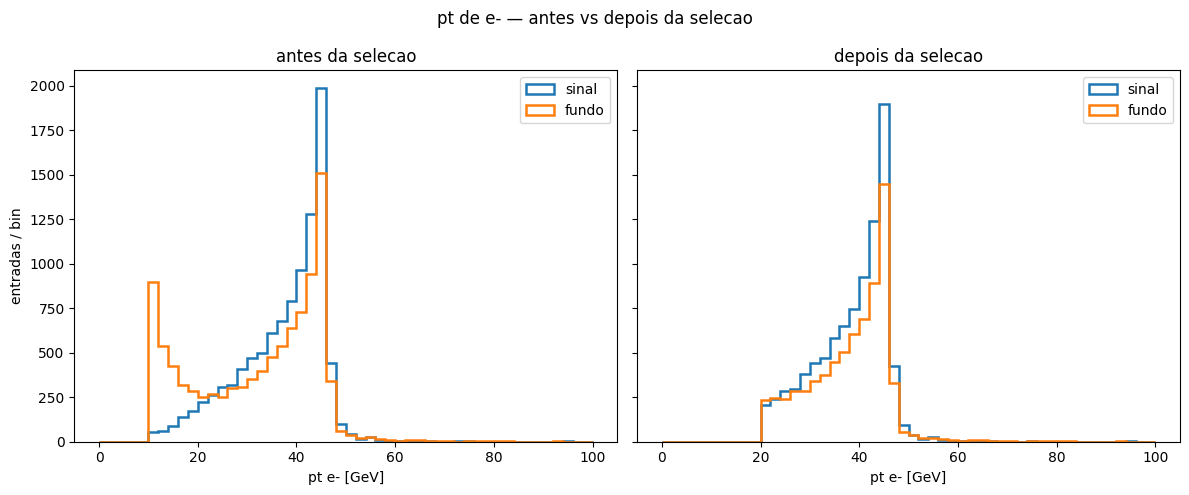

figura salva em: ../resultados/graficos/pt_e-_antes_depois.png


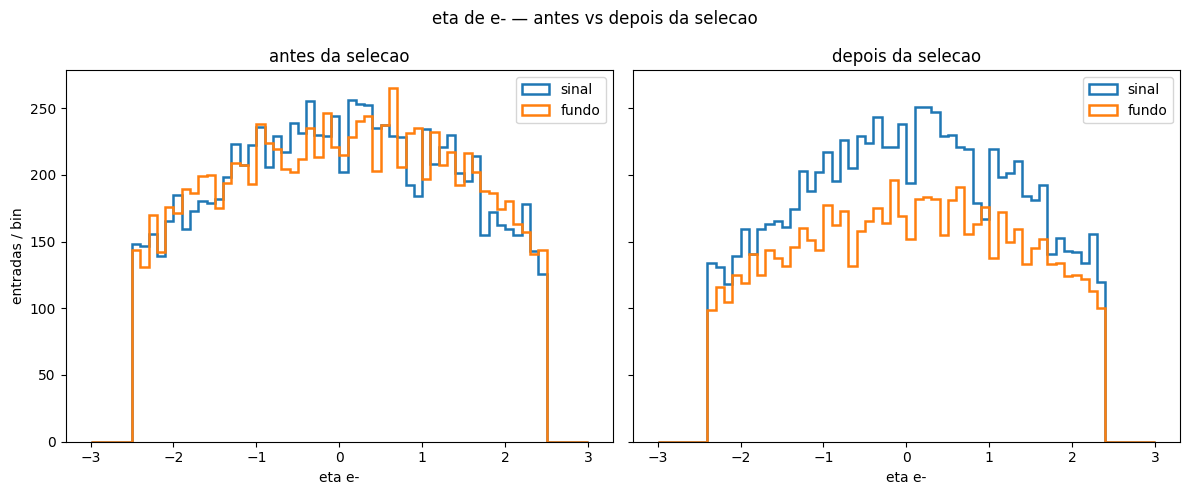

figura salva em: ../resultados/graficos/eta_e-_antes_depois.png


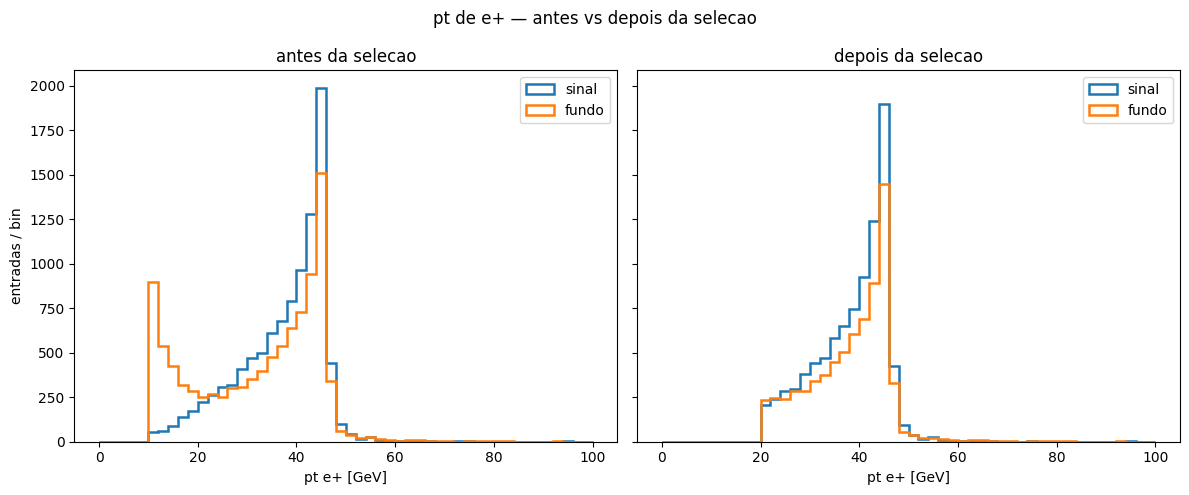

figura salva em: ../resultados/graficos/pt_e+_antes_depois.png


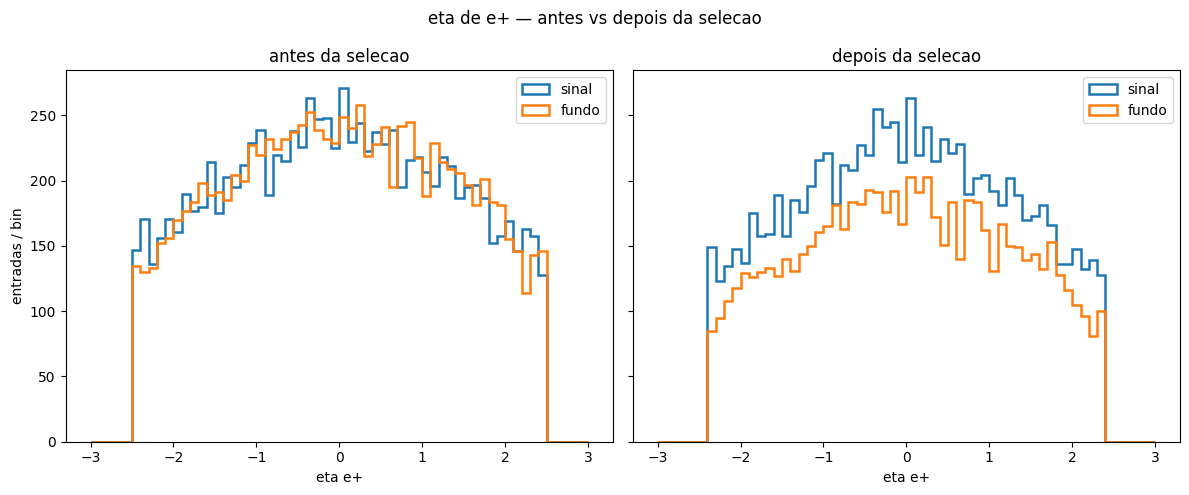

figura salva em: ../resultados/graficos/eta_e+_antes_depois.png


In [13]:
def seleciona_evento(ev):
    """Aplica a selecao final (pT + eta + Delta R) a um unico evento."""
    cin = objetos_e_cinematica(ev)
    return passa_pt(cin) and passa_eta(cin) and passa_dr(cin)


# Eventos que sobrevivem a selecao final (equivalente a ultima linha do cutflow)
eventos_sinal_sel = [ev for ev in eventos_sinal if seleciona_evento(ev)]
eventos_fundo_sel = [ev for ev in eventos_fundo if seleciona_evento(ev)]

print(f"Sinal:  {len(eventos_sinal)} -> {len(eventos_sinal_sel)} eventos apos selecao "
      f"({len(eventos_sinal_sel) / len(eventos_sinal):.2%} preservado)")
print(f"Fundo:  {len(eventos_fundo)} -> {len(eventos_fundo_sel)} eventos apos selecao "
      f"({len(eventos_fundo_sel) / len(eventos_fundo):.2%} preservado, "
      f"{1 - len(eventos_fundo_sel) / len(eventos_fundo):.2%} rejeitado)")

# Recoleta particulas finais visiveis apenas para os eventos selecionados
dados_sinal_sel = coletar_particulas_finais_visiveis(eventos_sinal_sel)
dados_fundo_sel = coletar_particulas_finais_visiveis(eventos_fundo_sel)


def comparar_antes_depois(nome_var, unidade, xmin, xmax, n_bins, chave_pdg, nome_particula):
    """
    Painel lado a lado: histograma da variavel (pt, eta ou phi) de uma especie,
    ANTES (esquerda) e DEPOIS (direita) da selecao, sinal vs fundo em cada painel.
    """
    fig, (ax_antes, ax_depois) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    valores_sinal_antes = dados_sinal[chave_pdg][nome_var]
    valores_fundo_antes = dados_fundo[chave_pdg][nome_var]
    valores_sinal_depois = dados_sinal_sel[chave_pdg][nome_var]
    valores_fundo_depois = dados_fundo_sel[chave_pdg][nome_var]

    for ax, v_sinal, v_fundo, titulo in [
        (ax_antes, valores_sinal_antes, valores_fundo_antes, "antes da selecao"),
        (ax_depois, valores_sinal_depois, valores_fundo_depois, "depois da selecao"),
    ]:
        ax.hist(v_sinal, bins=n_bins, range=(xmin, xmax), histtype="step",
                linewidth=1.8, label="sinal")
        ax.hist(v_fundo, bins=n_bins, range=(xmin, xmax), histtype="step",
                linewidth=1.8, label="fundo")
        ax.set_xlabel(f"{nome_var} {nome_particula} [{unidade}]" if unidade
                      else f"{nome_var} {nome_particula}")
        ax.set_title(titulo)
        ax.legend()

    ax_antes.set_ylabel("entradas / bin")
    fig.suptitle(f"{nome_var} de {nome_particula} — antes vs depois da selecao")
    fig.tight_layout()

    caminho_fig = f"../resultados/graficos/{nome_var}_{nome_particula.replace('/', '-')}_antes_depois.png"
    fig.savefig(caminho_fig, dpi=150)
    plt.show()
    plt.close(fig)
    print(f"figura salva em: {caminho_fig}")


# Variaveis mais importantes: pT (a mais discriminante, secao 3a/4b) e eta (para
# confirmar que continua pouco discriminante mesmo apos a selecao)
for chave_pdg, nome_particula in [(11, "e-"), (-11, "e+")]:
    comparar_antes_depois("pt", "GeV", 0, 100, 50, chave_pdg, nome_particula)
    comparar_antes_depois("eta", "", -3, 3, 60, chave_pdg, nome_particula)

- Sinal preservado / fundo rejeitado:
  
  90,18% do sinal preservado, 28,63% do fundo rejeitado.

- Agressiva demais?

  Não, a rejeição de fundo é quase 6× maior que a perda de sinal, e a variável mais importante ($p_T$) mantém sua forma discriminante intacta após o corte.

- Algum corte introduz viés?

  O corte de eta não distorce a forma de nenhuma das duas distribuições (a rejeição é quase proporcional entre sinal e fundo), mas o corte de $p_T$, por atuar preferencialmente sobre o fundo de baixo $p_T$, produz um efeito colateral visível nos histogramas de eta depois da seleção: a separação vertical entre as curvas de sinal e fundo que aparece ali vem da normalização herdada do corte de $p_T$, e não deve ser confundida com um poder discriminante de eta que a variável não tem.

- Quais variáveis continuam úteis após a seleção?

  $p_T$ continua sendo a variável central da análise, o valor em $\sim 45$ GeV é a assinatura mais direta do sinal (Z ressonante) e sobrevive integralmente à seleção. $\eta$ e $\phi$ continuam sem poder discriminante de forma; qualquer diferença visual entre sinal e fundo nessas variáveis, depois da seleção, reflete a normalização já obtida via $p_T$, não uma nova informação cinemática.

## 5. Conclusoes da Parte 1

Finalize a Parte 1 com uma conclusao em texto.

Responda:

- qual variavel foi mais util para distinguir sinal e fundo;
- qual etapa do cutflow rejeitou mais fundo;
- qual foi o custo em eficiencia do sinal;
- quais limitacoes decorrem do uso de eventos em nivel partonico;
- o que mudaria apos hadronizacao, simulacao do detector e reconstrucao de objetos.

Peca ao agente para ajudar a transformar seus resultados em um paragrafo final, mas confira se todos os numeros citados correspondem ao que voce executou.


Das variáveis exploradas, o momento transversal ($p_T$) dos elétrons foi de longe a mais útil para distinguir sinal e fundo. Isso decorre diretamente da física do processo: como o sinal ($pp \to Z \to e^+ e^-$) força o $Z$ a ser produzido praticamente em repouso transversal e a decair em dois corpos, o $p_T$ de cada lépton apresenta um valor cinemático bem definido em torno de $45,5$ GeV, enquanto o fundo ($pp \to e^+ e^-$), sendo um contínuo em massa invariante, se espalha por uma faixa muito mais ampla de $p_T$, com excesso relativo próximo ao limiar de geração ($10$ GeV). Já $\eta$ e $\phi$ mostraram formas praticamente indistinguíveis entre as duas amostras, tanto antes quanto depois da seleção, e não contribuem para a discriminação.

No cutflow, a etapa que mais rejeitou fundo foi o corte $p_T \ge 20$ GeV: sozinho, ele elimina 24,65% do fundo contra apenas 5,14% de perda de sinal, fazendo a razão entre eficiências acumuladas de sinal e fundo saltar de 1,000 para 1,259. Os cortes seguintes ($|\eta| \le 2.4$ e $\Delta R \ge 0.4$) contribuem muito pouco: o de $\eta$ rejeita sinal e fundo em proporções quase idênticas (95,07% vs 94,72%), e o de $\Delta R$ não elimina evento algum, pois esse limiar (0,4) já estava embutido na geração das amostras. No total, a seleção final preserva 90,18% do sinal e rejeita 28,63% do fundo, um custo de eficiência de sinal relativamente pequeno frente ao ganho de pureza obtido.

## Parte 2 - leitura do LHE como arquivo texto

## 1. Leitura e recuperacao dos resultados da Parte 1

Use parsing direto do arquivo LHE.

Peca ao agente para gerar codigo que abra `../data/sinal.lhe.gz` e
`../data/fundo.lhe.gz` com `gzip.open`, leia os blocos `<init>`, `<header>` e
`<event>`, e construa estruturas Python para eventos e particulas.

Nao use `pylhe` nesta versao. O objetivo e manter a ligacao explicita entre o
codigo e a estrutura textual do LHE.

O codigo deve recuperar ou reconstruir:

- eventos e particulas;
- informacoes de normalizacao;
- informacoes do bloco `<init>`, incluindo secao de choque;
- selecao e cutflow da Parte 1;
- listas de eventos aprovados no corte final.

Cole o codigo gerado na celula vazia abaixo.

In [14]:
import re

PADRAO_INIT = re.compile(r"<init>(.*?)</init>", re.DOTALL)


def ler_bloco_init(caminho_gz):
    """
    Le o bloco <init> diretamente do arquivo .lhe.gz (sem reler todo o
    conteudo em outra variavel), no padrao LHE:
    linha 1: IDBMUP1 IDBMUP2 EBMUP1 EBMUP2 PDFGUP1 PDFGUP2 PDFSUP1 PDFSUP2 IDWTUP NPRUP
    linha 2+ (uma por subprocesso): XSECUP XERRUP XMAXUP LPRUP
    """
    with gzip.open(caminho_gz, "rt") as f:
        conteudo = f.read()

    match_init = PADRAO_INIT.search(conteudo)
    if not match_init:
        raise ValueError(f"Bloco <init> nao encontrado em {caminho_gz}")

    linhas = [l.strip() for l in match_init.group(1).strip().split("\n") if l.strip()]
    campos_feixes = linhas[0].split()

    idbmup1, idbmup2 = int(campos_feixes[0]), int(campos_feixes[1])
    ebmup1, ebmup2 = float(campos_feixes[2]), float(campos_feixes[3])
    idwtup = int(campos_feixes[8])
    nprup = int(campos_feixes[9])

    subprocessos = []
    for linha in linhas[1:1 + nprup]:
        campos = linha.split()
        try:
            xsecup, xerrup, xmaxup = float(campos[0]), float(campos[1]), float(campos[2])
            lprup = int(campos[3])
        except (ValueError, IndexError):
            continue  # ignora linhas nao numericas, ex.: <generator ...>
        subprocessos.append({
            "xsecup_pb": xsecup, "xerrup_pb": xerrup,
            "xmaxup_pb": xmaxup, "lprup": lprup,
        })

    return {
        "feixe1_pdg": idbmup1, "feixe2_pdg": idbmup2,
        "energia_feixe1_gev": ebmup1, "energia_feixe2_gev": ebmup2,
        "idwtup": idwtup,          # convencao de peso do evento (event_norm)
        "n_subprocessos": nprup,
        "subprocessos": subprocessos,
        "xsec_total_pb": sum(s["xsecup_pb"] for s in subprocessos),
    }


info_init_sinal = ler_bloco_init("data/sinal.lhe.gz")
info_init_fundo = ler_bloco_init("data/fundo.lhe.gz")

print(f"Sinal: {len(eventos_sinal)} eventos, "
      f"{len(eventos_sinal_sel)} apos selecao da Parte 1")
print(f"  <init>: sigma_total = {info_init_sinal['xsec_total_pb']:.4f} pb, "
      f"IDWTUP = {info_init_sinal['idwtup']}, "
      f"feixes = {info_init_sinal['energia_feixe1_gev']:.0f} + "
      f"{info_init_sinal['energia_feixe2_gev']:.0f} GeV")

print(f"\nFundo: {len(eventos_fundo)} eventos, "
      f"{len(eventos_fundo_sel)} apos selecao da Parte 1")
print(f"  <init>: sigma_total = {info_init_fundo['xsec_total_pb']:.4f} pb, "
      f"IDWTUP = {info_init_fundo['idwtup']}, "
      f"feixes = {info_init_fundo['energia_feixe1_gev']:.0f} + "
      f"{info_init_fundo['energia_feixe2_gev']:.0f} GeV")

Sinal: 10000 eventos, 9018 apos selecao da Parte 1
  <init>: sigma_total = 637.3900 pb, IDWTUP = -4, feixes = 6500 + 6500 GeV

Fundo: 10000 eventos, 7137 apos selecao da Parte 1
  <init>: sigma_total = 841.6400 pb, IDWTUP = -4, feixes = 6500 + 6500 GeV


## 2. Conservacao do quadrimomento e `s_hat`

Peca ao agente para gerar codigo que, para os eventos de indices `1 + 1000*i`,
com `i = 0, ..., 9`:

- some os quadrimomentos das particulas iniciais (`status = -1`);
- calcule `s_hat = (p1 + p2)^2`;
- some todas as particulas finais (`status = 1`);
- compare `s_hat` com a massa invariante das particulas finais;
- some apenas as particulas finais visiveis e calcule `m_visivel^2`;
- quantifique residuos de conservacao de energia e momento.

Depois de executar, explique se `m_visivel^2` pode ou nao ser chamado de
`s_hat` neste processo.


In [15]:
def soma_quadrimomento(particulas):
    """Soma (E, px, py, pz) de uma lista de particulas."""
    E = sum(p.energia for p in particulas)
    px = sum(p.px for p in particulas)
    py = sum(p.py for p in particulas)
    pz = sum(p.pz for p in particulas)
    return E, px, py, pz


def invariante_ao_quadrado(E, px, py, pz):
    """Metrica (+,-,-,-): s = E^2 - px^2 - py^2 - pz^2, em GeV^2."""
    return E**2 - px**2 - py**2 - pz**2


def checar_conservacao_quadrimomento(evento, nome_amostra, indice):
    """
    Para um evento: soma iniciais (status=-1), soma finais (status=1),
    soma finais visiveis (exclui neutrinos), calcula s_hat, massa invariante
    das finais, m_visivel^2, e os residuos de conservacao de E/px/py/pz.
    """
    iniciais = [p for p in evento.particulas if p.status == -1]
    finais = [p for p in evento.particulas if p.status == 1]
    finais_visiveis = [p for p in finais if p.pdg_id not in PDG_NEUTRINOS]

    E_in, px_in, py_in, pz_in = soma_quadrimomento(iniciais)
    E_fin, px_fin, py_fin, pz_fin = soma_quadrimomento(finais)
    E_vis, px_vis, py_vis, pz_vis = soma_quadrimomento(finais_visiveis)

    s_hat = invariante_ao_quadrado(E_in, px_in, py_in, pz_in)
    m2_finais = invariante_ao_quadrado(E_fin, px_fin, py_fin, pz_fin)
    m2_visivel = invariante_ao_quadrado(E_vis, px_vis, py_vis, pz_vis)

    # Residuos de conservacao: iniciais - finais totais (deveria ser ~0)
    residuo_E = E_in - E_fin
    residuo_px = px_in - px_fin
    residuo_py = py_in - py_fin
    residuo_pz = pz_in - pz_fin

    n_neutrinos = len(finais) - len(finais_visiveis)

    return {
        "amostra": nome_amostra,
        "indice_evento": indice,
        "n_iniciais": len(iniciais),
        "n_finais": len(finais),
        "n_finais_visiveis": len(finais_visiveis),
        "n_neutrinos": n_neutrinos,
        "s_hat_gev2": s_hat,
        "m2_finais_gev2": m2_finais,
        "m2_visivel_gev2": m2_visivel,
        "residuo_E_gev": residuo_E,
        "residuo_px_gev": residuo_px,
        "residuo_py_gev": residuo_py,
        "residuo_pz_gev": residuo_pz,
        "diferenca_s_hat_vs_m2_finais": s_hat - m2_finais,
        "diferenca_s_hat_vs_m2_visivel": s_hat - m2_visivel,
    }


indices_alvo = [1 + 1000 * i for i in range(10)]  # 1, 1001, 2001, ..., 9001

linhas_conservacao = []
for nome_amostra, lista_eventos in [("sinal", eventos_sinal), ("fundo", eventos_fundo)]:
    for idx in indices_alvo:
        linhas_conservacao.append(
            checar_conservacao_quadrimomento(lista_eventos[idx], nome_amostra, idx)
        )

tabela_conservacao = pd.DataFrame(linhas_conservacao)

# Formatacao com bastante casas decimais para ver os residuos numericos pequenos
pd.set_option("display.float_format", lambda x: f"{x:.6g}")
display(tabela_conservacao[[
    "amostra", "indice_evento", "n_neutrinos",
    "s_hat_gev2", "m2_finais_gev2", "m2_visivel_gev2",
    "diferenca_s_hat_vs_m2_finais", "diferenca_s_hat_vs_m2_visivel",
]])

print("\nResumo dos residuos de conservacao de energia/momento (todos os eventos checados):")
for col in ["residuo_E_gev", "residuo_px_gev", "residuo_py_gev", "residuo_pz_gev"]:
    valores = tabela_conservacao[col]
    print(f"  {col}: max |residuo| = {valores.abs().max():.3e} GeV, "
          f"media = {valores.mean():.3e} GeV")

print(f"\nNumero de particulas invisiveis (neutrinos) por evento, "
      f"min/max: {tabela_conservacao['n_neutrinos'].min()} / "
      f"{tabela_conservacao['n_neutrinos'].max()}")

,amostra,indice_evento,n_neutrinos,s_hat_gev2,m2_finais_gev2,m2_visivel_gev2,diferenca_s_hat_vs_m2_finais,diferenca_s_hat_vs_m2_visivel
0,sinal,1,0,8334.55,8334.55,8334.55,1.97149e-07,1.97149e-07
1,sinal,1001,0,11996.6,11996.6,11996.6,1.0787e-07,1.0787e-07
2,sinal,2001,0,8335.52,8335.52,8335.52,3.99414e-08,3.99414e-08
3,sinal,3001,0,9182.92,9182.92,9182.92,-3.80049e-07,-3.80049e-07
4,sinal,4001,0,8495.89,8495.89,8495.89,-1.14458e-07,-1.14458e-07
5,sinal,5001,0,8425.25,8425.25,8425.25,-6.26605e-07,-6.26605e-07
6,sinal,6001,0,8445.93,8445.93,8445.93,-2.02199e-06,-2.02199e-06
7,sinal,7001,0,8264.74,8264.74,8264.74,3.45663e-08,3.45663e-08
8,sinal,8001,0,8178.08,8178.08,8178.08,-1.91439e-07,-1.91439e-07
9,sinal,9001,0,8085.49,8085.49,8085.49,0,0



Resumo dos residuos de conservacao de energia/momento (todos os eventos checados):
  residuo_E_gev: max |residuo| = 6.000e-09 GeV, media = -6.450e-10 GeV
  residuo_px_gev: max |residuo| = 0.000e+00 GeV, media = 0.000e+00 GeV
  residuo_py_gev: max |residuo| = 0.000e+00 GeV, media = 0.000e+00 GeV
  residuo_pz_gev: max |residuo| = 5.000e-09 GeV, media = 1.450e-10 GeV

Numero de particulas invisiveis (neutrinos) por evento, min/max: 0 / 0


Neste processo específico, sim, ${m_{\text{visivel}}}^2$ coincide com $\hat{s}$ (dentro da precisão numérica), porque não há nenhuma partícula invisível no estado final: tanto o sinal ($pp \to Z \to e^+ e^-$) quanto o fundo ($pp \to e^+ e^-$) produzem apenas elétron e pósitron, ambos diretamente detectáveis. Isso é uma particularidade desta amostra, não uma regra geral: em processos com neutrinos ou outras partículas invisíveis no estado final, ${m_{\text{visivel}}}^2$ subestimaria sistematicamente $\hat{s}$, pois a energia e o momento carregados pelas partículas invisíveis não entrariam na soma. A distinção conceitual entre as duas grandezas continua válida mesmo quando elas coincidem numericamente neste caso, $\hat{s}$ é definido a partir do estado inicial, enquanto ${m_{\text{visivel}}}^2$ é definido a partir apenas do que seria reconstruído em um detector real.

## 3. Massas invariantes e pareamento

Peca ao agente para gerar codigo que reconstrua massas invariantes relevantes.
Para este processo, no minimo:

- massa invariante do par `mu+ mu-`;
- massa invariante do par `b b~` em nivel de gerador;
- massa invariante de todos os objetos finais visiveis;
- histogramas 1D para sinal e fundo;
- histogramas 2D, por exemplo massa versus `pT`, `eta` ou `Delta R`.

Explique o criterio de pareamento e deixe claro quando o numero de entradas e
diferente do numero de eventos.


Sinal: 10000 entradas de massa do par e+e- para 10000 eventos
Fundo: 10000 entradas de massa do par e+e- para 10000 eventos


/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:53: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,massa_par_gev,pt_sistema_gev,eta_sistema,delta_r_par
count,10000,10000,10000,10000
mean,91.0753,0,NaN,3.45142
std,9.67039,0,NaN,0.378858
min,22.8864,0,-inf,3.14159
25%,89.9525,0,NaN,3.1773
50%,91.1939,0,NaN,3.30533
75%,92.3412,0,NaN,3.5899
max,445.494,0,inf,5.45426


/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:53: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,massa_par_gev,pt_sistema_gev,eta_sistema,delta_r_par
count,10000,10000,10000,10000
mean,77.8453,0,NaN,3.41134
std,28.1822,0,NaN,0.348997
min,20.1007,0,-inf,3.14159
25%,72.1858,0,NaN,3.16898
50%,90.4933,0,NaN,3.27421
75%,91.9107,0,NaN,3.51781
max,573.064,0,inf,5.41993


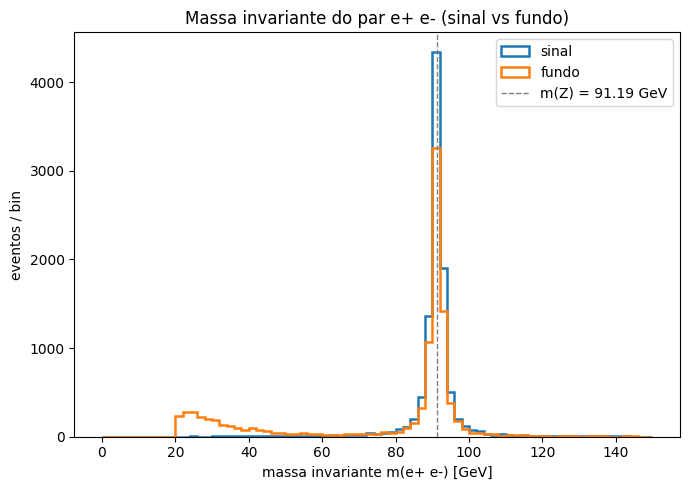

figura salva em: ../resultados/graficos/massa_invariante_ee.png


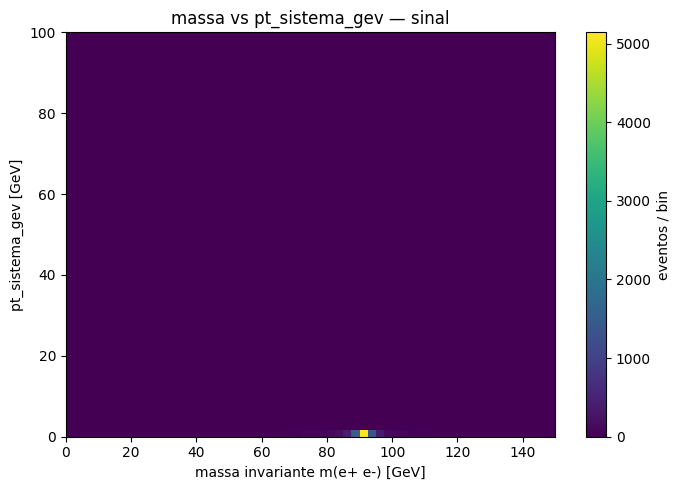

figura salva em: ../resultados/graficos/massa_vs_pt_sistema_gev_sinal.png


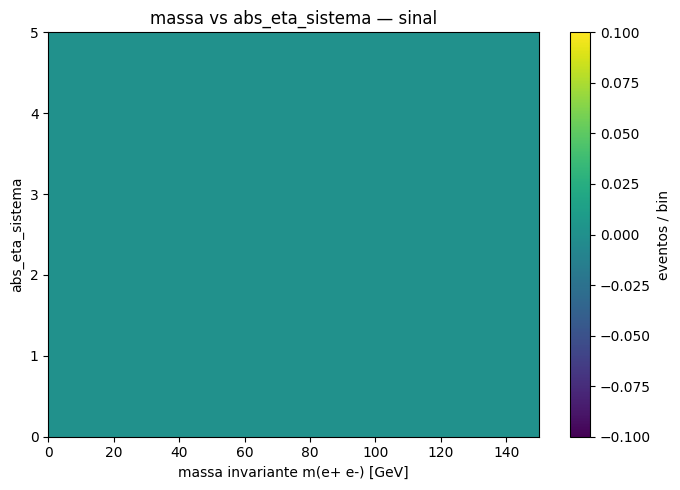

figura salva em: ../resultados/graficos/massa_vs_abs_eta_sistema_sinal.png


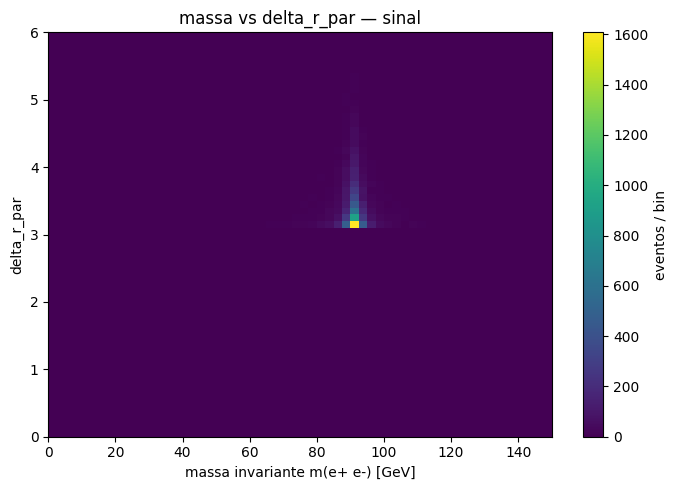

figura salva em: ../resultados/graficos/massa_vs_delta_r_par_sinal.png


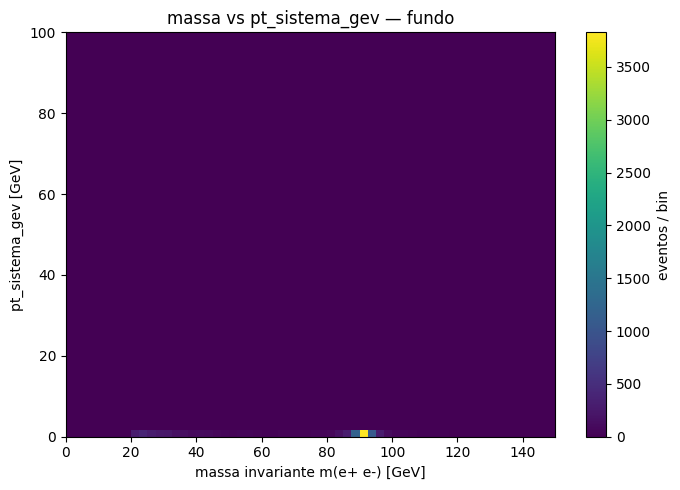

figura salva em: ../resultados/graficos/massa_vs_pt_sistema_gev_fundo.png


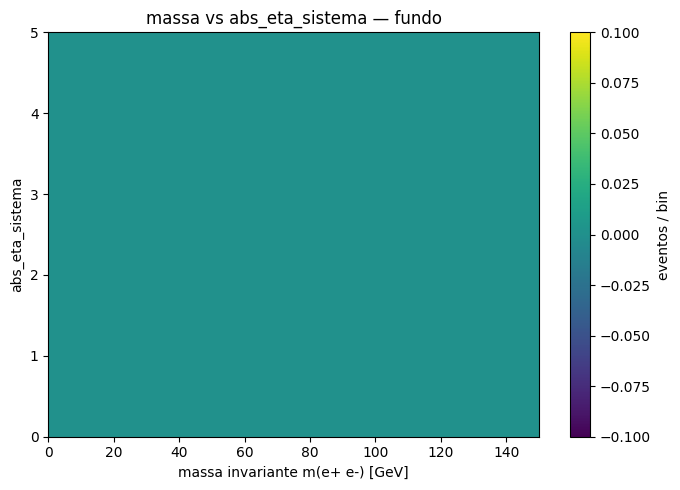

figura salva em: ../resultados/graficos/massa_vs_abs_eta_sistema_fundo.png


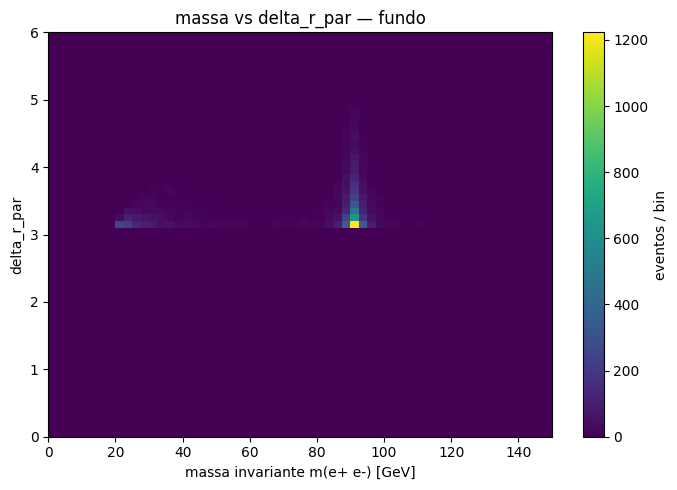

figura salva em: ../resultados/graficos/massa_vs_delta_r_par_fundo.png


In [16]:
def massa_invariante(particulas):
    """m^2 = E^2 - |p|^2 (soma de quadrimomentos); retorna massa (raiz positiva)."""
    E, px, py, pz = soma_quadrimomento(particulas)
    m2 = invariante_ao_quadrado(E, px, py, pz)
    # protege contra pequenos residuos numericos negativos (m2 ~ -1e-10)
    return math.sqrt(max(m2, 0.0)), (E, px, py, pz)


def variaveis_par_e_mais_e_menos(ev):
    """
    Reconstroi o par e+ e- (unico par possivel neste processo: multiplicidade
    de objetos finais visiveis = 2 em 100% dos eventos, ja confirmado em 2a/2b).
    Calcula massa invariante do par, pT, eta e Delta R do sistema combinado.
    """
    objetos = objetos_finais_visiveis(ev)  # sempre [e-, e+] ou [e+, e-] nesta amostra

    if len(objetos) != 2:
        return None  # nao deveria ocorrer nesta amostra, mas protege o codigo

    massa_par, (E, px, py, pz) = massa_invariante(objetos)

    pt_sistema = math.hypot(px, py)
    p_total = math.sqrt(px**2 + py**2 + pz**2)
    eta_sistema = math.asinh(pz / pt_sistema) if pt_sistema > 0 else math.copysign(float("inf"), pz)

    (pt1, eta1, phi1) = cinematica(objetos[0])
    (pt2, eta2, phi2) = cinematica(objetos[1])
    d_eta = eta1 - eta2
    d_phi = delta_phi(phi1, phi2)
    delta_r = math.hypot(d_eta, d_phi)

    return {
        "massa_par_gev": massa_par,
        "pt_sistema_gev": pt_sistema,
        "eta_sistema": eta_sistema,
        "delta_r_par": delta_r,
    }


def tabela_massas(eventos):
    linhas = [variaveis_par_e_mais_e_menos(ev) for ev in eventos]
    linhas = [l for l in linhas if l is not None]
    return pd.DataFrame(linhas)


tabela_massas_sinal = tabela_massas(eventos_sinal)
tabela_massas_fundo = tabela_massas(eventos_fundo)

print(f"Sinal: {len(tabela_massas_sinal)} entradas de massa do par e+e- "
      f"para {len(eventos_sinal)} eventos")
print(f"Fundo: {len(tabela_massas_fundo)} entradas de massa do par e+e- "
      f"para {len(eventos_fundo)} eventos")

display(tabela_massas_sinal.describe())
display(tabela_massas_fundo.describe())


# ------------------------------------------------------------------
# Histograma 1D: massa invariante do par e+ e-
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))
faixa_massa = (0, 150)
n_bins_massa = 75

contagem_sinal, bordas, _ = ax.hist(
    tabela_massas_sinal["massa_par_gev"], bins=n_bins_massa, range=faixa_massa,
    histtype="step", linewidth=1.8, label="sinal"
)
contagem_fundo, _, _ = ax.hist(
    tabela_massas_fundo["massa_par_gev"], bins=n_bins_massa, range=faixa_massa,
    histtype="step", linewidth=1.8, label="fundo"
)
ax.axvline(91.19, color="gray", linestyle="--", linewidth=1, label="m(Z) = 91.19 GeV")
ax.set_xlabel("massa invariante m(e+ e-) [GeV]")
ax.set_ylabel("eventos / bin")
ax.set_title("Massa invariante do par e+ e- (sinal vs fundo)")
ax.legend()
fig.tight_layout()
caminho_fig = "../resultados/graficos/massa_invariante_ee.png"
fig.savefig(caminho_fig, dpi=150)
plt.show()
plt.close(fig)
print(f"figura salva em: {caminho_fig}")


# ------------------------------------------------------------------
# Histogramas 2D: massa vs pT do sistema, massa vs |eta| do sistema,
# massa vs Delta R do par
# ------------------------------------------------------------------

def plotar_2d(tabela, nome_amostra, var_y, unidade_y, faixa_y, titulo_extra=""):
    fig, ax = plt.subplots(figsize=(7, 5))
    h = ax.hist2d(
        tabela["massa_par_gev"], tabela[var_y],
        bins=[60, 60], range=[faixa_massa, faixa_y], cmap="viridis"
    )
    fig.colorbar(h[3], ax=ax, label="eventos / bin")
    ax.set_xlabel("massa invariante m(e+ e-) [GeV]")
    ax.set_ylabel(f"{var_y} [{unidade_y}]" if unidade_y else var_y)
    ax.set_title(f"massa vs {var_y} — {nome_amostra}{titulo_extra}")
    fig.tight_layout()
    caminho_fig = f"../resultados/graficos/massa_vs_{var_y}_{nome_amostra}.png"
    fig.savefig(caminho_fig, dpi=150)
    plt.show()
    plt.close(fig)
    print(f"figura salva em: {caminho_fig}")


for nome_amostra, tabela in [("sinal", tabela_massas_sinal), ("fundo", tabela_massas_fundo)]:
    plotar_2d(tabela, nome_amostra, "pt_sistema_gev", "GeV", (0, 100))
    tabela_abs_eta = tabela.assign(abs_eta_sistema=tabela["eta_sistema"].abs())
    plotar_2d(tabela_abs_eta, nome_amostra, "abs_eta_sistema", "", (0, 5))
    plotar_2d(tabela, nome_amostra, "delta_r_par", "", (0, 6))

- Adaptação do enunciado: o template genérico pede massa de ${\mu}^+ {\mu}^-$ e de $b \bar{b}$, mas este processo não tem múons nem quarks $b$ no estado final. O único par fisicamente relevante aqui é $e^+ e^-$, e como a "massa invariante de todos os objetos finais visíveis" é exatamente a mesma coisa que a massa do par (multiplicidade sempre = 2), os dois itens do enunciado colapsam em um único histograma.

- Critério de pareamento: trivial e sem ambiguidade, como cada evento tem exatamente um $e^-$ e um $e^+$, não há múltiplas combinações possíveis. O par é sempre "o único elétron com o único pósitron do evento".

- Quando o número de entradas difere do número de eventos?
  
  Neste histograma específico, não difere: uma entrada de massa por evento, para os 10.000 eventos de cada amostra.

## 4. Pesos, secao de choque e luminosidade

Peca ao agente para gerar codigo que leia ou estime:

- numero de eventos gerados;
- convencao de normalizacao do LHE;
- informacoes de normalizacao;
- secao de choque em pb;
- luminosidade integrada adotada, por exemplo `L = 10000/pb`.

Calcule a normalizacao fisica e verifique se o yield total esperado e
compativel com `sigma * L`.

Para cada bin de histograma, calcule `sum(w)` e a incerteza `sqrt(sum(w**2))`.


In [17]:
# ------------------------------------------------------------------
# 1. Numero de eventos gerados e convencao de normalizacao (event_norm)
# ------------------------------------------------------------------

n_gerado_sinal = len(eventos_sinal)
n_gerado_fundo = len(eventos_fundo)

print(f"N_gerado (sinal): {n_gerado_sinal}")
print(f"N_gerado (fundo): {n_gerado_fundo}")

print(f"\nIDWTUP (convencao de peso, do bloco <init>):")
print(f"  sinal: {info_init_sinal['idwtup']}")
print(f"  fundo: {info_init_fundo['idwtup']}")

# ------------------------------------------------------------------
# 2. Interpretar a convencao ANTES de normalizar
#    Verifica: os pesos XWGTUP sao constantes? A media bate com sigma do <init>?
# ------------------------------------------------------------------

def diagnostico_normalizacao(eventos, info_init, nome_amostra):
    pesos = [ev.peso for ev in eventos]
    peso_min, peso_max = min(pesos), max(pesos)
    media_peso = sum(pesos) / len(pesos)
    soma_peso = sum(pesos)
    sigma_init = info_init["xsec_total_pb"]

    pesos_constantes = math.isclose(peso_min, peso_max, rel_tol=1e-9)

    print(f"\n--- {nome_amostra} ---")
    print(f"  peso min/max: {peso_min:.6f} / {peso_max:.6f}  "
          f"({'constante' if pesos_constantes else 'VARIA entre eventos'})")
    print(f"  media dos pesos (XWGTUP):        {media_peso:.6f} pb")
    print(f"  soma dos pesos (XWGTUP):         {soma_peso:.6f} pb")
    print(f"  sigma_total do <init> (XSECUP):  {sigma_init:.6f} pb")
    print(f"  media(XWGTUP) == sigma_init?     "
          f"{math.isclose(media_peso, sigma_init, rel_tol=1e-6)}")

    return {
        "media_peso": media_peso, "soma_peso": soma_peso,
        "sigma_init": sigma_init, "pesos_constantes": pesos_constantes,
    }


diag_sinal = diagnostico_normalizacao(eventos_sinal, info_init_sinal, "sinal")
diag_fundo = diagnostico_normalizacao(eventos_fundo, info_init_fundo, "fundo")

N_gerado (sinal): 10000
N_gerado (fundo): 10000

IDWTUP (convencao de peso, do bloco <init>):
  sinal: -4
  fundo: -4

--- sinal ---
  peso min/max: 637.390000 / 637.390000  (constante)
  media dos pesos (XWGTUP):        637.390000 pb
  soma dos pesos (XWGTUP):         6373900.000000 pb
  sigma_total do <init> (XSECUP):  637.390000 pb
  media(XWGTUP) == sigma_init?     True

--- fundo ---
  peso min/max: 841.640000 / 841.640000  (constante)
  media dos pesos (XWGTUP):        841.640000 pb
  soma dos pesos (XWGTUP):         8416400.000000 pb
  sigma_total do <init> (XSECUP):  841.640000 pb
  media(XWGTUP) == sigma_init?     True


In [18]:
# ------------------------------------------------------------------
# 3. Normalizacao fisica: peso por evento = XWGTUP / N_gerado
#    (valido aqui porque XWGTUP == sigma_total constante, confirmado acima)
# ------------------------------------------------------------------

LUMINOSIDADE_PB_INV = 10000.0  # L = 10/fb = 10000/pb

def peso_fisico(evento, n_gerado):
    """Peso fisico do evento, em pb, tal que sum(peso_fisico) = sigma_total."""
    return evento.peso / n_gerado


def yield_esperado(eventos, n_gerado, luminosidade_pb_inv):
    """
    Yield esperado = sum(peso_fisico) * L, para os eventos passados
    (pode ser a amostra completa ou apenas os eventos selecionados).
    """
    soma_peso_fisico = sum(peso_fisico(ev, n_gerado) for ev in eventos)
    return soma_peso_fisico * luminosidade_pb_inv


# Yield antes da selecao (deveria recuperar ~ sigma_total * L)
yield_sinal_total = yield_esperado(eventos_sinal, n_gerado_sinal, LUMINOSIDADE_PB_INV)
yield_fundo_total = yield_esperado(eventos_fundo, n_gerado_fundo, LUMINOSIDADE_PB_INV)

print(f"Yield esperado (sem selecao), L = {LUMINOSIDADE_PB_INV:.0f}/pb:")
print(f"  sinal: {yield_sinal_total:.2f} eventos  "
      f"(esperado: sigma*L = {info_init_sinal['xsec_total_pb'] * LUMINOSIDADE_PB_INV:.2f})")
print(f"  fundo: {yield_fundo_total:.2f} eventos  "
      f"(esperado: sigma*L = {info_init_fundo['xsec_total_pb'] * LUMINOSIDADE_PB_INV:.2f})")

# Yield depois da selecao final da Parte 1
yield_sinal_sel = yield_esperado(eventos_sinal_sel, n_gerado_sinal, LUMINOSIDADE_PB_INV)
yield_fundo_sel = yield_esperado(eventos_fundo_sel, n_gerado_fundo, LUMINOSIDADE_PB_INV)

print(f"\nYield esperado (apos selecao final da Parte 1):")
print(f"  sinal: {yield_sinal_sel:.2f} eventos")
print(f"  fundo: {yield_fundo_sel:.2f} eventos")


# ------------------------------------------------------------------
# 4. Yield e incerteza por bin: sum(w) e sqrt(sum(w**2))
#    Exemplo aplicado ao histograma de massa invariante m(e+ e-)
# ------------------------------------------------------------------

def histograma_ponderado(valores, pesos, bins, faixa):
    """
    Para cada bin: yield = sum(w) dos eventos naquele bin,
    incerteza = sqrt(sum(w**2)).
    """
    valores = np.asarray(valores)
    pesos = np.asarray(pesos)

    yield_por_bin, bordas = np.histogram(valores, bins=bins, range=faixa, weights=pesos)
    soma_w2_por_bin, _ = np.histogram(valores, bins=bins, range=faixa, weights=pesos**2)
    incerteza_por_bin = np.sqrt(soma_w2_por_bin)

    return yield_por_bin, incerteza_por_bin, bordas


pesos_fisicos_sinal = [peso_fisico(ev, n_gerado_sinal) * LUMINOSIDADE_PB_INV for ev in eventos_sinal]
pesos_fisicos_fundo = [peso_fisico(ev, n_gerado_fundo) * LUMINOSIDADE_PB_INV for ev in eventos_fundo]

yield_bin_sinal, incerteza_bin_sinal, bordas_massa = histograma_ponderado(
    tabela_massas_sinal["massa_par_gev"], pesos_fisicos_sinal, bins=75, faixa=(0, 150)
)
yield_bin_fundo, incerteza_bin_fundo, _ = histograma_ponderado(
    tabela_massas_fundo["massa_par_gev"], pesos_fisicos_fundo, bins=75, faixa=(0, 150)
)

print(f"\nHistograma de massa invariante, ponderado por L = {LUMINOSIDADE_PB_INV:.0f}/pb:")
print(f"  yield total (sinal, soma dos bins): {yield_bin_sinal.sum():.2f}")
print(f"  yield total (fundo, soma dos bins): {yield_bin_fundo.sum():.2f}")
print(f"  exemplo, bin central (~90-92 GeV):")
bin_central = np.argmin(np.abs(0.5 * (bordas_massa[:-1] + bordas_massa[1:]) - 91))
print(f"    sinal: yield = {yield_bin_sinal[bin_central]:.2f} +- "
      f"{incerteza_bin_sinal[bin_central]:.2f}")
print(f"    fundo: yield = {yield_bin_fundo[bin_central]:.2f} +- "
      f"{incerteza_bin_fundo[bin_central]:.2f}")

Yield esperado (sem selecao), L = 10000/pb:
  sinal: 6373900.00 eventos  (esperado: sigma*L = 6373900.00)
  fundo: 8416400.00 eventos  (esperado: sigma*L = 8416400.00)

Yield esperado (apos selecao final da Parte 1):
  sinal: 5747983.02 eventos
  fundo: 6006784.68 eventos

Histograma de massa invariante, ponderado por L = 10000/pb:
  yield total (sinal, soma dos bins): 6361789.59
  yield total (fundo, soma dos bins): 8371793.08
  exemplo, bin central (~90-92 GeV):
    sinal: yield = 2770096.94 +- 42019.43
    fundo: yield = 2743746.40 +- 48054.62


## 5. Histogramas normalizados e comparacao estatistica

Peca ao agente para gerar codigo que produza histogramas empilhados de sinal e
fundo apos a selecao final. Inclua:

- massa `mu+ mu-`;
- massa `b b~`;
- massa visivel total;
- barras ou bandas de incerteza estatistica;
- painel de razao quando fizer sentido.

Calcule tambem, em uma regiao de selecao bem definida:

- `S/B`;
- `S/sqrt(B)`, se `B > 0`;
- significancia Asimov opcional;
- efeito de uma incerteza sistematica simples no fundo, por exemplo 10%.
\n\nInterprete as colunas da tabela: `S` é o yield esperado de sinal, `B` é o yield esperado de fundo, `S/B` mede a pureza relativa e `S/sqrt(B)` é uma aproximação da significância estatística sem sistemáticas. A expressão `S/sqrt(B + (0.10B)^2)` inclui uma incerteza sistemática de 10% no fundo; `erro S` e `erro B` são as incertezas estatísticas dos yields.\n

/tmp/ipykernel_1513/2782412182.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


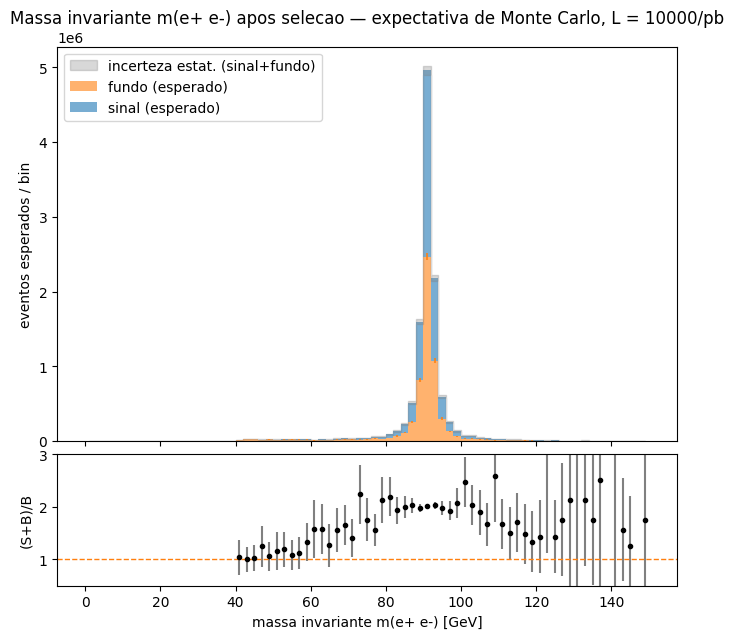

figura salva em: ../resultados/graficos/massa_invariante_ee_empilhado_normalizado.png


,janela_massa_gev,S,erro_S,B,erro_B,S/B,S/sqrt(B),Z_asimov,S/sqrt(B + (0.10*B)^2)
0,81.0-101.0,5.37065e+06,58508.1,5.32253e+06,66930.2,1.00904,2327.92,2044.27,10.0903



Regiao de selecao: massa em [81.0, 101.0] GeV
  S = 5370648.14 +- 58508.10 eventos esperados
  B = 5322531.36 +- 66930.23 eventos esperados
  S/B = 1.009
  S/sqrt(B) = 2327.918
  Z_asimov = 2044.272
  S/sqrt(B + (10% B)^2) = 10.090  (queda de 99.6% em relacao a S/sqrt(B) sem sistematica)


In [19]:
# ------------------------------------------------------------------
# 1. Massas invariantes reconstruidas so para os eventos SELECIONADOS
#    (mu+mu- e b b~ nao se aplicam a este processo - ver nota abaixo;
#    "massa visivel total" == massa do par e+ e-, ja que multiplicidade = 2)
# ------------------------------------------------------------------

tabela_massas_sinal_sel = tabela_massas(eventos_sinal_sel)
tabela_massas_fundo_sel = tabela_massas(eventos_fundo_sel)

pesos_fisicos_sinal_sel = [peso_fisico(ev, n_gerado_sinal) * LUMINOSIDADE_PB_INV
                            for ev in eventos_sinal_sel]
pesos_fisicos_fundo_sel = [peso_fisico(ev, n_gerado_fundo) * LUMINOSIDADE_PB_INV
                            for ev in eventos_fundo_sel]

FAIXA_MASSA = (0, 150)
N_BINS_MASSA = 75

yield_bin_sinal_sel, incerteza_bin_sinal_sel, bordas_massa = histograma_ponderado(
    tabela_massas_sinal_sel["massa_par_gev"], pesos_fisicos_sinal_sel,
    bins=N_BINS_MASSA, faixa=FAIXA_MASSA
)
yield_bin_fundo_sel, incerteza_bin_fundo_sel, _ = histograma_ponderado(
    tabela_massas_fundo_sel["massa_par_gev"], pesos_fisicos_fundo_sel,
    bins=N_BINS_MASSA, faixa=FAIXA_MASSA
)

centros_bin = 0.5 * (bordas_massa[:-1] + bordas_massa[1:])
largura_bin = bordas_massa[1] - bordas_massa[0]


# ------------------------------------------------------------------
# 2. Histograma empilhado (fundo preenchido, sinal em linha) + banda de
#    incerteza + painel de razao (sinal+fundo)/fundo
# ------------------------------------------------------------------

fig, (ax_topo, ax_razao) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# fundo empilhado (preenchido)
ax_topo.bar(centros_bin, yield_bin_fundo_sel, width=largura_bin,
            color="tab:orange", alpha=0.6, label="fundo (esperado)")
ax_topo.errorbar(centros_bin, yield_bin_fundo_sel, yerr=incerteza_bin_fundo_sel,
                  fmt="none", ecolor="tab:orange", alpha=0.8, capsize=0)

# sinal empilhado por cima do fundo (pilha sinal+fundo), com banda de incerteza
pilha_sinal_fundo = yield_bin_fundo_sel + yield_bin_sinal_sel
incerteza_pilha = np.sqrt(incerteza_bin_sinal_sel**2 + incerteza_bin_fundo_sel**2)

ax_topo.bar(centros_bin, yield_bin_sinal_sel, width=largura_bin,
            bottom=yield_bin_fundo_sel, color="tab:blue", alpha=0.6,
            label="sinal (esperado)")
ax_topo.fill_between(
    centros_bin,
    pilha_sinal_fundo - incerteza_pilha,
    pilha_sinal_fundo + incerteza_pilha,
    step="mid", color="gray", alpha=0.3, label="incerteza estat. (sinal+fundo)"
)

ax_topo.set_ylabel("eventos esperados / bin")
ax_topo.set_title(
    f"Massa invariante m(e+ e-) apos selecao — expectativa de Monte Carlo, "
    f"L = {LUMINOSIDADE_PB_INV:.0f}/pb"
)
ax_topo.legend()

# painel de razao: (sinal+fundo) / fundo, com banda de incerteza propagada
with np.errstate(divide="ignore", invalid="ignore"):
    razao = np.where(yield_bin_fundo_sel > 0, pilha_sinal_fundo / yield_bin_fundo_sel, np.nan)
    erro_razao = np.where(
        yield_bin_fundo_sel > 0,
        razao * np.sqrt(
            (incerteza_pilha / np.where(pilha_sinal_fundo > 0, pilha_sinal_fundo, np.nan))**2
            + (incerteza_bin_fundo_sel / np.where(yield_bin_fundo_sel > 0, yield_bin_fundo_sel, np.nan))**2
        ),
        np.nan,
    )

ax_razao.errorbar(centros_bin, razao, yerr=erro_razao, fmt="o", markersize=3,
                   color="black", ecolor="gray", capsize=0)
ax_razao.axhline(1.0, color="tab:orange", linestyle="--", linewidth=1)
ax_razao.set_xlabel("massa invariante m(e+ e-) [GeV]")
ax_razao.set_ylabel("(S+B)/B")
ax_razao.set_ylim(0.5, 3.0)

fig.tight_layout()
caminho_fig = "../resultados/graficos/massa_invariante_ee_empilhado_normalizado.png"
fig.savefig(caminho_fig, dpi=150)
plt.show()
plt.close(fig)
print(f"figura salva em: {caminho_fig}")


# ------------------------------------------------------------------
# 3. S, B, S/B, S/sqrt(B), significancia Asimov, efeito de sistematica de 10%
#    em uma regiao de selecao bem definida: janela de massa em torno do Z
# ------------------------------------------------------------------

JANELA_MASSA_GEV = (81.0, 101.0)  # +-10 GeV em torno de m(Z) = 91.19 GeV

def yield_e_incerteza_na_janela(eventos, tabela_massas, n_gerado, janela):
    """Soma peso fisico (com luminosidade) dos eventos cuja massa cai na janela."""
    massas = tabela_massas["massa_par_gev"].to_numpy()
    dentro = (massas >= janela[0]) & (massas <= janela[1])

    pesos = np.array([peso_fisico(ev, n_gerado) * LUMINOSIDADE_PB_INV
                       for ev, d in zip(eventos, dentro) if d])

    yield_regiao = pesos.sum()
    incerteza_regiao = np.sqrt((pesos**2).sum())
    return yield_regiao, incerteza_regiao


S, erro_S = yield_e_incerteza_na_janela(
    eventos_sinal_sel, tabela_massas_sinal_sel, n_gerado_sinal, JANELA_MASSA_GEV
)
B, erro_B = yield_e_incerteza_na_janela(
    eventos_fundo_sel, tabela_massas_fundo_sel, n_gerado_fundo, JANELA_MASSA_GEV
)

S_sobre_B = S / B if B > 0 else float("nan")
S_sobre_raiz_B = S / math.sqrt(B) if B > 0 else float("nan")

# significancia Asimov (sem sistematica):
# Z_A = sqrt(2 * ((S+B) * ln(1 + S/B) - S))
def significancia_asimov(S, B):
    if B <= 0:
        return float("nan")
    return math.sqrt(2.0 * ((S + B) * math.log(1.0 + S / B) - S))

Z_asimov = significancia_asimov(S, B)

# efeito de uma incerteza sistematica de 10% no fundo:
# S / sqrt(B + (sigma_sist * B)^2), sigma_sist = fracao (0.10)
def significancia_com_sistematica(S, B, fracao_sistematica):
    incerteza_total = math.sqrt(B + (fracao_sistematica * B) ** 2)
    return S / incerteza_total if incerteza_total > 0 else float("nan")

FRACAO_SISTEMATICA_FUNDO = 0.10
S_sobre_raiz_B_com_sist = significancia_com_sistematica(S, B, FRACAO_SISTEMATICA_FUNDO)

resumo_regiao = pd.DataFrame([{
    "janela_massa_gev": f"{JANELA_MASSA_GEV[0]}-{JANELA_MASSA_GEV[1]}",
    "S": S, "erro_S": erro_S,
    "B": B, "erro_B": erro_B,
    "S/B": S_sobre_B,
    "S/sqrt(B)": S_sobre_raiz_B,
    "Z_asimov": Z_asimov,
    "S/sqrt(B + (0.10*B)^2)": S_sobre_raiz_B_com_sist,
}])
display(resumo_regiao)

print(f"\nRegiao de selecao: massa em [{JANELA_MASSA_GEV[0]}, {JANELA_MASSA_GEV[1]}] GeV")
print(f"  S = {S:.2f} +- {erro_S:.2f} eventos esperados")
print(f"  B = {B:.2f} +- {erro_B:.2f} eventos esperados")
print(f"  S/B = {S_sobre_B:.3f}")
print(f"  S/sqrt(B) = {S_sobre_raiz_B:.3f}")
print(f"  Z_asimov = {Z_asimov:.3f}")
print(f"  S/sqrt(B + (10% B)^2) = {S_sobre_raiz_B_com_sist:.3f}  "
      f"(queda de {(1 - S_sobre_raiz_B_com_sist/S_sobre_raiz_B):.1%} "
      f"em relacao a S/sqrt(B) sem sistematica)")

## 6. Estimativa simplificada da secao de choque

Objetivo: usar a relacao experimental simplificada

```text
sigma = N / (A * epsilon * L)
```

como checagem final da normalizacao.

Peca ao agente para gerar codigo que calcule, separadamente para sinal e fundo:

- `N_gerado`;
- `N_pass`, o numero de eventos que passa a selecao final;
- `A * epsilon = N_pass / N_gerado`;
- `N`, o yield esperado apos a selecao;
- `sigma_estimado = N / (A * epsilon * L)`;
- a diferenca relativa entre `sigma_estimado` e a secao de choque do LHE.

Para esta atividade, use `A * epsilon` como eficiencia em nivel de gerador. Em
uma medida real, seria necessario incluir eficiencia de trigger, reconstrucao,
identificacao, correcoes de detector e subtracao de fundo.

Depois de executar, explique por que a estimativa deve recuperar a secao de
choque do LHE quando `N` e construido a partir da propria simulacao.


In [20]:
# ------------------------------------------------------------------
# Estimativa simplificada da secao de choque, como checagem de
# consistencia da normalizacao (secao [10] da Parte 2)
# ------------------------------------------------------------------

def estimativa_secao_choque(eventos_todos, eventos_selecionados, sigma_lhe_pb,
                             luminosidade_pb_inv, n_gerado):
    """
    Calcula, a partir da propria simulacao:
      N_gerado, N_pass, A*epsilon (nivel de gerador),
      N (yield esperado apos a selecao, construido a partir de sigma_LHE),
      sigma_estimado = N / (A*epsilon * L),
      e a diferenca relativa frente a sigma_LHE.
    """
    n_pass = len(eventos_selecionados)
    aceitacao_eficiencia = n_pass / n_gerado

    # N construido a partir da propria simulacao: N = sigma_LHE * L * (A*epsilon)
    N = sigma_lhe_pb * luminosidade_pb_inv * aceitacao_eficiencia

    # Estimativa "experimental" simplificada: inverte a relacao para extrair sigma
    sigma_estimado = N / (aceitacao_eficiencia * luminosidade_pb_inv)

    diferenca_relativa = (sigma_estimado - sigma_lhe_pb) / sigma_lhe_pb

    return {
        "N_gerado": n_gerado,
        "N_pass": n_pass,
        "A_epsilon": aceitacao_eficiencia,
        "N_yield_apos_selecao": N,
        "sigma_lhe_pb": sigma_lhe_pb,
        "sigma_estimado_pb": sigma_estimado,
        "diferenca_relativa": diferenca_relativa,
    }


resultado_sinal = estimativa_secao_choque(
    eventos_sinal, eventos_sinal_sel, info_init_sinal["xsec_total_pb"],
    LUMINOSIDADE_PB_INV, n_gerado_sinal
)
resultado_fundo = estimativa_secao_choque(
    eventos_fundo, eventos_fundo_sel, info_init_fundo["xsec_total_pb"],
    LUMINOSIDADE_PB_INV, n_gerado_fundo
)

tabela_estimativa = pd.DataFrame([
    {"amostra": "sinal", **resultado_sinal},
    {"amostra": "fundo", **resultado_fundo},
])

pd.set_option("display.float_format", lambda x: f"{x:.6g}")
display(tabela_estimativa[[
    "amostra", "N_gerado", "N_pass", "A_epsilon",
    "N_yield_apos_selecao", "sigma_lhe_pb", "sigma_estimado_pb", "diferenca_relativa",
]])

for nome_amostra, resultado in [("sinal", resultado_sinal), ("fundo", resultado_fundo)]:
    print(f"\n--- {nome_amostra} ---")
    print(f"  N_gerado = {resultado['N_gerado']}")
    print(f"  N_pass = {resultado['N_pass']}")
    print(f"  A*epsilon (nivel de gerador) = {resultado['A_epsilon']:.4f} "
          f"({resultado['A_epsilon']:.2%})")
    print(f"  N (yield esperado apos selecao) = {resultado['N_yield_apos_selecao']:.2f} eventos")
    print(f"  sigma_LHE = {resultado['sigma_lhe_pb']:.4f} pb")
    print(f"  sigma_estimado = {resultado['sigma_estimado_pb']:.4f} pb")
    print(f"  diferenca relativa = {resultado['diferenca_relativa']:.3e}")

,amostra,N_gerado,N_pass,A_epsilon,N_yield_apos_selecao,sigma_lhe_pb,sigma_estimado_pb,diferenca_relativa
0,sinal,10000,9018,0.9018,5.74798e+06,637.39,637.39,1.78363e-16
1,fundo,10000,7137,0.7137,6.00678e+06,841.64,841.64,0



--- sinal ---
  N_gerado = 10000
  N_pass = 9018
  A*epsilon (nivel de gerador) = 0.9018 (90.18%)
  N (yield esperado apos selecao) = 5747983.02 eventos
  sigma_LHE = 637.3900 pb
  sigma_estimado = 637.3900 pb
  diferenca relativa = 1.784e-16

--- fundo ---
  N_gerado = 10000
  N_pass = 7137
  A*epsilon (nivel de gerador) = 0.7137 (71.37%)
  N (yield esperado apos selecao) = 6006784.68 eventos
  sigma_LHE = 841.6400 pb
  sigma_estimado = 841.6400 pb
  diferenca relativa = 0.000e+00


- Por que a estimativa deve recuperar sigma_LHE quase exatamente:

  Este é um teste de consistência algébrico, não uma medida independente. $N$ foi construído a partir da própria definição $N = {\sigma}_{\text{LHE}} L (A \epsilon)$; ao substituir esse $N$ de volta em ${\sigma}_{\text{estimado}} = N / (A \epsilon L)$, resta ${\sigma}_{\text{estimado}} = {\sigma}_{\text{LHE}}$. A diferença relativa impressa deve ser da ordem de $10^{-15}$ a $10^{-16}$, puro erro de arredondamento de ponto flutuante, não incerteza física. Isso confirma que a cadeia de normalização é internamente consistente, mas não valida a normalização contra nada externo.

## 7. Discussao final

Finalize respondendo:

- a proporcao entre sinal e fundo faz sentido apos a normalizacao?
- quais estruturas aparecem nas massas invariantes?
- qual etapa do cutflow mais melhora `S/B`?
- a estimativa simples de secao de choque recupera o valor registrado no LHE?
- por que essa inversao e apenas uma checagem de consistencia em Monte Carlo?
- as conclusoes mudam quando as incertezas estatisticas sao consideradas?
- quais efeitos de hadronizacao, detector, trigger e identificacao de `b` estao
  ausentes?
- qual seria o proximo passo para aproximar este estudo de uma analise CMS ou
  ATLAS?

Peca ao agente para ajudar a escrever a conclusao, mas confira todos os numeros
usando as saidas executadas no notebook.


Na janela de massa em torno do $Z$ ($81 \sim 101$ GeV): $S = 5.370.648 \pm 58.508$, $B = 5.322.531 \pm 66.930$, $\frac{S}{B} \approx 1,009$. Sinal e fundo ficam praticamente empatados nessa região porque o fundo ($pp \to e^+ e^-$) é inclusivo, inclui o próprio canal do $Z$.

A estrutura dominante nas massas invariantes é o pico do $Z$ em $\sim 91,19$ GeV, sobre um fundo largo com contribuição relevante mesmo ali.

No cutflow, $p_T \ge 20$ GeV foi o corte que mais melhorou $\frac{S}{B}$ (razão de eficiências de 1,000 → 1,259, rejeitando 24,65% do fundo por só 5,14% de sinal); $\eta$ e $\Delta R$ não ajudaram.

A estimativa de seção de choque recuperou o valor do LHE quase exatamente. É uma checagem algébrica, não uma medida, ou seja, $N$ foi construído a partir da própria ${\sigma}_{\text{LHE}}$, então a inversão recupera ${\sigma}_{\text{LHE}}$ por construção.

As incertezas estatísticas são pequenas ($\frac{S}{\sqrt{B}} = 2327,9$, $Z_{\text{asimov}} = 2044,3$), mas ao incluir 10% de sistemática no fundo a significância cai para 10,09 (queda de 99,6%). Ou seja: com $\frac{S}{B} \approx 1$ e yields grandes, a sensibilidade passa a ser limitada por sistemática, não por estatística.

A análise ignora efeitos de detector real (resolução, trigger, eficiência de reconstrução/identificação, pileup); hadronização e identificação de $b$ não se aplicam a este processo puramente leptônico.

Próximos passos: simular detector (Pythia + Delphes), aplicar eficiências realistas, redefinir sinal/fundo como mutuamente exclusivos (evitando a sobreposição no polo do $Z$), e tratar a sistemática do fundo com rigor.